In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import os 
print(os.getcwd())

d:\BookRecommendation\notebook


In [3]:
df = pd.read_csv(r'd:\BookRecommendation\data\processed\clean_book_ratings.csv')

In [4]:
df

,index,ISBN,Book_Title,Book_Author,Year_Of_Publication,Publisher,User_ID,Book_Rating,Age_Group,Country
0,30,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,8,0,Unknown,canada
1,31,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,11676,9,Unknown,Unknown
2,32,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,29526,9,Adult,usa
3,33,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,36836,0,Senior,usa
4,34,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,46398,9,Middle_Age,usa
...,...,...,...,...,...,...,...,...,...,...
188377,1015621,0689823185,Where You Belong,Mary Ann McGuigan,1998,Simon Pulse,242299,0,Young_Adult,usa
188378,1016510,0553290703,Lightning,Patricia Potter,1992,Bantam Books,244685,9,Unknown,Unknown
188379,1016522,0345478940,Angel Falls,KRISTIN HANNAH,2004,Ballantine Books,244688,0,Adult,usa
188380,1016538,B00011SOYM,Grave Secrets,Kathy Reichs,2002,Scribner,244708,0,Unknown,united kingdom


In [5]:
df.reset_index(drop = True )

,index,ISBN,Book_Title,Book_Author,Year_Of_Publication,Publisher,User_ID,Book_Rating,Age_Group,Country
0,30,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,8,0,Unknown,canada
1,31,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,11676,9,Unknown,Unknown
2,32,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,29526,9,Adult,usa
3,33,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,36836,0,Senior,usa
4,34,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,46398,9,Middle_Age,usa
...,...,...,...,...,...,...,...,...,...,...
188377,1015621,0689823185,Where You Belong,Mary Ann McGuigan,1998,Simon Pulse,242299,0,Young_Adult,usa
188378,1016510,0553290703,Lightning,Patricia Potter,1992,Bantam Books,244685,9,Unknown,Unknown
188379,1016522,0345478940,Angel Falls,KRISTIN HANNAH,2004,Ballantine Books,244688,0,Adult,usa
188380,1016538,B00011SOYM,Grave Secrets,Kathy Reichs,2002,Scribner,244708,0,Unknown,united kingdom


In [6]:
print(df.columns.tolist())   # Saare column names dikhao
print(df.head(3))            # Pehle 3 rows dikhao

['index', 'ISBN', 'Book_Title', 'Book_Author', 'Year_Of_Publication', 'Publisher', 'User_ID', 'Book_Rating', 'Age_Group', 'Country']
   index        ISBN              Book_Title Book_Author  Year_Of_Publication  \
0     30  0399135782  The Kitchen God's Wife     Amy Tan                 1991   
1     31  0399135782  The Kitchen God's Wife     Amy Tan                 1991   
2     32  0399135782  The Kitchen God's Wife     Amy Tan                 1991   

          Publisher  User_ID  Book_Rating Age_Group  Country  
0  Putnam Pub Group        8            0   Unknown   canada  
1  Putnam Pub Group    11676            9   Unknown  Unknown  
2  Putnam Pub Group    29526            9     Adult      usa  


In [7]:
df = df.reset_index(drop= True)

In [8]:
df

,index,ISBN,Book_Title,Book_Author,Year_Of_Publication,Publisher,User_ID,Book_Rating,Age_Group,Country
0,30,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,8,0,Unknown,canada
1,31,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,11676,9,Unknown,Unknown
2,32,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,29526,9,Adult,usa
3,33,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,36836,0,Senior,usa
4,34,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,46398,9,Middle_Age,usa
...,...,...,...,...,...,...,...,...,...,...
188377,1015621,0689823185,Where You Belong,Mary Ann McGuigan,1998,Simon Pulse,242299,0,Young_Adult,usa
188378,1016510,0553290703,Lightning,Patricia Potter,1992,Bantam Books,244685,9,Unknown,Unknown
188379,1016522,0345478940,Angel Falls,KRISTIN HANNAH,2004,Ballantine Books,244688,0,Adult,usa
188380,1016538,B00011SOYM,Grave Secrets,Kathy Reichs,2002,Scribner,244708,0,Unknown,united kingdom


In [9]:
df.shape

(188382, 10)

In [10]:
df.drop(columns=['index'],inplace=True)

In [11]:
df

,ISBN,Book_Title,Book_Author,Year_Of_Publication,Publisher,User_ID,Book_Rating,Age_Group,Country
0,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,8,0,Unknown,canada
1,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,11676,9,Unknown,Unknown
2,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,29526,9,Adult,usa
3,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,36836,0,Senior,usa
4,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,46398,9,Middle_Age,usa
...,...,...,...,...,...,...,...,...,...
188377,0689823185,Where You Belong,Mary Ann McGuigan,1998,Simon Pulse,242299,0,Young_Adult,usa
188378,0553290703,Lightning,Patricia Potter,1992,Bantam Books,244685,9,Unknown,Unknown
188379,0345478940,Angel Falls,KRISTIN HANNAH,2004,Ballantine Books,244688,0,Adult,usa
188380,B00011SOYM,Grave Secrets,Kathy Reichs,2002,Scribner,244708,0,Unknown,united kingdom


In [12]:
user_feature = pd.DataFrame()

In [13]:
user_feature = df.groupby('User_ID').agg({
    'Book_Rating': ['mean', 'count', 'std']
})

In [14]:
user_feature.shape

(7807, 3)

In [15]:
user_feature

Book_Rating                
               mean count       std
User_ID                            
8          0.000000     1       NaN
242        6.000000     3  5.291503
243        2.050847    59  3.486050
254        2.044944    89  3.720063
383        1.250000     8  3.535534
...             ...   ...       ...
278582     5.529412    17  4.094473
278633     4.275000    40  4.138546
278637     0.000000     1       NaN
278843     3.869565    23  4.159374
278851     8.000000     1       NaN

[7807 rows x 3 columns]

In [16]:
user_feature.columns = ['user_avg_rating', 'user_rating_count', 'user_rating_std']
user_feature.reset_index(inplace=True)

In [17]:
user_feature

,User_ID,user_avg_rating,user_rating_count,user_rating_std
0,8,0.000000,1,NaN
1,242,6.000000,3,5.291503
2,243,2.050847,59,3.486050
3,254,2.044944,89,3.720063
4,383,1.250000,8,3.535534
...,...,...,...,...
7802,278582,5.529412,17,4.094473
7803,278633,4.275000,40,4.138546
7804,278637,0.000000,1,NaN
7805,278843,3.869565,23,4.159374


In [18]:
user_demo = df[['User_ID', 'Age_Group', 'Country']].drop_duplicates()

user_feature = user_feature.merge(user_demo, on='User_ID', how='left')

In [19]:
user_feature

,User_ID,user_avg_rating,user_rating_count,user_rating_std,Age_Group,Country
0,8,0.000000,1,NaN,Unknown,canada
1,242,6.000000,3,5.291503,Middle_Age,germany
2,243,2.050847,59,3.486050,Unknown,usa
3,254,2.044944,89,3.720063,Young_Adult,usa
4,383,1.250000,8,3.535534,Unknown,usa
...,...,...,...,...,...,...
7802,278582,5.529412,17,4.094473,Unknown,usa
7803,278633,4.275000,40,4.138546,Unknown,usa
7804,278637,0.000000,1,NaN,Unknown,france
7805,278843,3.869565,23,4.159374,Adult,usa


In [20]:
fav_author = df.groupby(['User_ID', 'Book_Author']).size().reset_index(name='count')

fav_author = fav_author.sort_values(['User_ID', 'count'], ascending=[True, False])

fav_author = fav_author.drop_duplicates('User_ID')

fav_author = fav_author[['User_ID', 'Book_Author']]
fav_author.rename(columns={'Book_Author': 'favourite_author'}, inplace=True)

user_feature = user_feature.merge(fav_author, on='User_ID', how='left')

In [21]:
user_feature

,User_ID,user_avg_rating,user_rating_count,user_rating_std,Age_Group,Country,favourite_author
0,8,0.000000,1,NaN,Unknown,canada,Amy Tan
1,242,6.000000,3,5.291503,Middle_Age,germany,RAY BRADBURY
2,243,2.050847,59,3.486050,Unknown,usa,James Patterson
3,254,2.044944,89,3.720063,Young_Adult,usa,J. K. Rowling
4,383,1.250000,8,3.535534,Unknown,usa,John Grisham
...,...,...,...,...,...,...,...
7802,278582,5.529412,17,4.094473,Unknown,usa,Janet Evanovich
7803,278633,4.275000,40,4.138546,Unknown,usa,ANN BRASHARES
7804,278637,0.000000,1,NaN,Unknown,france,Patricia Cornwell
7805,278843,3.869565,23,4.159374,Adult,usa,Rebecca Wells


In [22]:
df['is_old'] = df['Year_Of_Publication'] < 2000
df['is_recent'] = df['Year_Of_Publication'] >= 2000

In [23]:
year_stats = df.groupby('User_ID').agg({
    'is_old': 'mean',
    'is_recent': 'mean'
}).reset_index()

year_stats.rename(columns={
    'is_old': 'old_books_ratio',
    'is_recent': 'recent_books_ratio'
}, inplace=True)

In [24]:
user_feature = user_feature.merge(year_stats, on='User_ID', how='left')

In [25]:
user_feature

,User_ID,user_avg_rating,user_rating_count,user_rating_std,Age_Group,Country,favourite_author,old_books_ratio,recent_books_ratio
0,8,0.000000,1,NaN,Unknown,canada,Amy Tan,1.000000,0.000000
1,242,6.000000,3,5.291503,Middle_Age,germany,RAY BRADBURY,0.666667,0.333333
2,243,2.050847,59,3.486050,Unknown,usa,James Patterson,0.576271,0.423729
3,254,2.044944,89,3.720063,Young_Adult,usa,J. K. Rowling,0.685393,0.314607
4,383,1.250000,8,3.535534,Unknown,usa,John Grisham,0.250000,0.750000
...,...,...,...,...,...,...,...,...,...
7802,278582,5.529412,17,4.094473,Unknown,usa,Janet Evanovich,0.352941,0.647059
7803,278633,4.275000,40,4.138546,Unknown,usa,ANN BRASHARES,0.700000,0.300000
7804,278637,0.000000,1,NaN,Unknown,france,Patricia Cornwell,1.000000,0.000000
7805,278843,3.869565,23,4.159374,Adult,usa,Rebecca Wells,0.782609,0.217391


In [26]:
df.isnull().sum()

ISBN                   0
Book_Title             0
Book_Author            0
Year_Of_Publication    0
Publisher              0
User_ID                0
Book_Rating            0
Age_Group              0
Country                0
is_old                 0
is_recent              0
dtype: int64

In [27]:
import os 

print(os.getcwd())

d:\BookRecommendation\notebook


In [28]:
genre_df = pd.read_csv(r'D:\BookRecommendation\data\raw\Goodreads_books_with_genres.csv')

In [29]:
df

,ISBN,Book_Title,Book_Author,Year_Of_Publication,Publisher,User_ID,Book_Rating,Age_Group,Country,is_old,is_recent
0,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,8,0,Unknown,canada,True,False
1,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,11676,9,Unknown,Unknown,True,False
2,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,29526,9,Adult,usa,True,False
3,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,36836,0,Senior,usa,True,False
4,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,46398,9,Middle_Age,usa,True,False
...,...,...,...,...,...,...,...,...,...,...,...
188377,0689823185,Where You Belong,Mary Ann McGuigan,1998,Simon Pulse,242299,0,Young_Adult,usa,True,False
188378,0553290703,Lightning,Patricia Potter,1992,Bantam Books,244685,9,Unknown,Unknown,True,False
188379,0345478940,Angel Falls,KRISTIN HANNAH,2004,Ballantine Books,244688,0,Adult,usa,False,True
188380,B00011SOYM,Grave Secrets,Kathy Reichs,2002,Scribner,244708,0,Unknown,united kingdom,False,True


In [30]:
df['Book_Author'].nunique()

1294

In [31]:
lst = [df['Book_Title'] ]

In [32]:
df['ISBN'].nunique()

5175

In [33]:
lst

[0                                 The Kitchen God's Wife
 1                                 The Kitchen God's Wife
 2                                 The Kitchen God's Wife
 3                                 The Kitchen God's Wife
 4                                 The Kitchen God's Wife
                                ...                      
 188377                                  Where You Belong
 188378                                         Lightning
 188379                                       Angel Falls
 188380                                     Grave Secrets
 188381    The Two Towers (The Lord of the Rings, Part 2)
 Name: Book_Title, Length: 188382, dtype: str]

In [34]:
# Unique title + author combinations
unique_books = df[['Book_Title', 'Book_Author']].drop_duplicates()
print(f"Total unique books: {len(unique_books)}")
print("\nPehle 50 books:")
print(unique_books.head(50).to_string())

Total unique books: 2675

Pehle 50 books:
                                                                        Book_Title             Book_Author
0                                                           The Kitchen God's Wife                 Amy Tan
22                                                                   The Testament            John Grisham
308                                           Beloved (Plume Contemporary Fiction)           Toni Morrison
439                                                                    Wild Animus            Rich Shapero
1661                                                                      Airframe        Michael Crichton
1801                                                                      Timeline        MICHAEL CRICHTON
2051                                                         To Kill a Mockingbird              Harper Lee
2325                                                Seabiscuit: An American Legend       LAURA HILLENB

In [35]:
unique_books.head(20)

,Book_Title,Book_Author
0,The Kitchen God's Wife,Amy Tan
22,The Testament,John Grisham
308,Beloved (Plume Contemporary Fiction),Toni Morrison
439,Wild Animus,Rich Shapero
1661,Airframe,Michael Crichton
1801,Timeline,MICHAEL CRICHTON
2051,To Kill a Mockingbird,Harper Lee
2325,Seabiscuit: An American Legend,LAURA HILLENBRAND
2469,Pigs in Heaven,Barbara Kingsolver
2499,Pride and Prejudice,Jane Austen


In [36]:
genre_data = {
    "The Kitchen God's Wife": "Fiction",
    "The Testament": "Legal Thriller",
    "Beloved (Plume Contemporary Fiction)": "Historical Fiction",
    "Wild Animus": "Adventure",
    "Airframe": "Techno-Thriller",
    "Timeline": "Science Fiction",
    "To Kill a Mockingbird": "Classic",
    "Seabiscuit: An American Legend": "Biography",
    "Pigs in Heaven": "Fiction",
    "Pride and Prejudice": "Romance",
    "Downtown": "Fiction",
    "Icebound": "Thriller",
    "I'll Be Seeing You": "Mystery",
    "From the Corner of His Eye": "Thriller",
    "Isle of Dogs": "Crime",
    "Purity in Death": "Crime",
    "This Year It Will Be Different": "Fiction",
    "Left Behind: A Novel of the Earth's Last Days": "Religious Fiction",
    "The Street Lawyer": "Legal Thriller",
    "Breathing Lessons": "Literary Fiction"
}

df['Genre'] = df['Book_Title'].map(genre_data)

In [37]:
next_20 = unique_books.iloc[20:40]
next_20

,Book_Title,Book_Author
3575,The Joy Luck Club,Amy Tan
3959,The Tao of Pooh,Benjamin Hoff
4096,Seabiscuit,LAURA HILLENBRAND
4222,Life's Little Instruction Book (Life's Little ...,H. Jackson Brown
4294,Starship Troopers,Robert A. Heinlein
4347,The Catcher in the Rye,J.D. Salinger
4587,Midnight in the Garden of Good and Evil: A Sav...,John Berendt
4770,Pretend You Don't See Her,Mary Higgins Clark
4907,Fast Women,Jennifer Crusie
4923,Female Intelligence,Jane Heller


In [38]:
genre_data.update({
    "The Joy Luck Club": "Fiction",
    "The Tao of Pooh": "Philosophy",
    "Seabiscuit": "Biography",
    "Life's Little Instruction Book": "Self-Help",
    "Starship Troopers": "Science Fiction",
    "The Catcher in the Rye": "Classic",
    "Midnight in the Garden of Good and Evil": "True Crime",
    "Pretend You Don't See Her": "Mystery",
    "Fast Women": "Romance",
    "Female Intelligence": "Fiction",
    "The Pillars of the Earth": "Historical Fiction",
    "Corelli's Mandolin : A Novel": "Historical Fiction",
    "The Five People You Meet in Heaven": "Inspirational",
    "The Alibi": "Thriller",
    "The Beach House": "Thriller",
    "Dead Aim": "Thriller",
    "Angels & Demons": "Thriller",
    "Every Breath You Take : A True Story": "True Crime",
    "The Girl Who Loved Tom Gordon": "Horror",
    "The Sum of All Fears": "Political Thriller"
})

In [39]:
df['Genre'] = df['Book_Title'].map(genre_data)

In [40]:
df['Genre'].isnull().sum()

np.int64(180875)

In [41]:
next_20 = unique_books.iloc[2650:2675]
next_20

,Book_Title,Book_Author
188287,Abduction,Charlotte Lamb
188290,Can You Keep a Secret?,SOPHIE KINSELLA
188298,The Rescue,Suzanne Robinson
188305,Now You See Me,Jean Bedford
188307,Riptide,John Lawton
188308,Courting Trouble,Katie Rose
188310,Journey,Patricia MacLachlan
188322,Killjoy,Elizabeth Forrest
188323,Courting Trouble,Nancy Fraser
188324,Harvest,Christopher Hart


In [42]:
genre_data.update({
    "Abduction": "Romantic Suspense",
    "Can You Keep a Secret?": "Romantic Comedy",
    "The Rescue": "Romance",
    "Now You See Me": "Psychological Thriller",
    "Riptide": "Thriller",
    "Courting Trouble": "Romance",
    "Journey": "Literary Fiction",
    "Killjoy": "Mystery",
    "Harvest": "Literary Fiction",
    "Blindsight": "Science Fiction",
    "No Safe Place": "Romantic Suspense",
    "Second Nature": "Romance",
    "Postmortem": "Crime Thriller",
    "Remember Me": "Romance",
    "Night": "Literary Fiction",
    "One True Thing": "Literary Fiction",
    "Between Friends": "Contemporary Fiction",
    "A Game of Thrones": "Epic Fantasy",
    "Ashes to Ashes": "Crime Fiction",
    "The Boy Next Door": "Romance",
    "Echoes": "Mystery",
    "The Promise": "Literary Fiction",
    "Where You Belong": "Romance",
    "Lightning": "Crime Thriller"
})

In [43]:
genre_data.update({
    "Over the Edge": "Thriller",
    "Lost and Found": "Romance",
    "Basket Case": "Mystery/Thriller",
    "Then Came Heaven": "Romance",
    "The Ugly Duckling": "Children's Classic",
    "The Promise": "Romance",
    "September": "Romance",
    "Bygones": "Romance",
    "The Ring": "Mystery",
    "Anne of Windy Poplars": "Children's Classic",
    "The Fool's Run": "Crime Thriller",
    "Guardian": "Romantic Suspense",
    "Untamed": "Romance",
    "Coming Home": "Romance",
    "Darkness": "Literary Fiction",
    "Wings": "Romance",
    "Breach of Promise": "Legal Thriller",
    "Lucky You": "Comedy Fiction",
    "Dead Aim": "Thriller",
    "The Lost World": "Adventure Fiction",
    "Rebecca": "Gothic Fiction",
    "Storming Heaven": "Military Fiction",
    "Bittersweet": "Romance",
    "Saving Grace": "Romance",
    "Shadows": "Horror",
    "The Indian in the Cupboard": "Children's Fiction",
    "Cause of Death": "True Crime",
    "Legend": "Western Fiction",
    "Misery": "Horror/Thriller",
    "Lost and Found": "Romance",
    "Silent Witness": "Mystery",
    "Midnight": "Horror",
    "Angels": "Religious Fiction",
    "The Secret": "Romance",
    "Archangel": "Fantasy",
    "From Potter's Field": "Crime Thriller",
    "Ashes to Ashes": "Crime Fiction",
    "Every Living Thing": "Children's Fiction",
    "Saving Faith": "Thriller",
    "Hideaway": "Romance",
    "Love": "Romance",
    "Flashback": "Thriller",
    "Protect and Defend": "Legal Thriller",
    "Wanderlust": "Literary Fiction",
    "Go Ask Alice": "Memoir",
    "The Mask": "Horror",
    "Blue Moon": "Romance"
})

In [44]:
genre_data.update({
    "Wings": "Romance",
    "No Greater Love": "Romance",
    "Remember Me": "Romance",
    "On the Road": "Literary Fiction",
    "Ashes to Ashes": "Crime Fiction",
    "Silent Witness": "Mystery",
    "Ringworld": "Science Fiction",
    "Out of Sight": "Crime Thriller",
    "Sanctuary": "Romance",
    "Dangerous": "Romance",
    "Angel": "Romance",
    "Intensity": "Psychological Thriller",
    "The Promise": "Romance",
    "Legend": "Western Fiction",
    "Trial by Fire": "Legal Thriller",
    "The Mask": "Horror",
    "Bitter Harvest": "Romance",
    "Surfacing": "Literary Fiction",
    "Flesh and Blood": "Literary Fiction",
    "Eaters of the Dead": "Historical Fiction",
    "The Gift": "Religious Fiction",
    "The Secret": "Romance",
    "Dark Angel": "Romantic Suspense",
    "Now and Forever": "Romance",
    "Promises": "Romance",
    "Secrets": "Romance",
    "Masquerade": "Mystery",
    "The Ugly Duckling": "Children's Classic",
    "Beloved": "Literary Fiction",
    "Journey": "Literary Fiction",
    "Over the Edge": "Thriller",
    "Archangel": "Fantasy",
    "Angels": "Religious Fiction",
    "The Bone Collector": "Crime Thriller",
    "Cradle and All": "Religious Thriller",
    "Palomino": "Romance",
    "Cause of Death": "True Crime",
    "Grave Secrets": "True Crime",
    "The Apprentice": "Psychological Thriller",
    "Tough Cookie": "Drama",
    "Faking It": "Romance",
    "The Secret": "Romance",
    "Reasonable Doubt": "Legal Thriller",
    "Temptation": "Romance",
    "Tapestry": "Romance"
})

In [45]:
genre_data.update({
    "Paradise": "Romance",
    "The Tailor of Panama": "Spy Thriller",
    "Now You See Me": "Psychological Thriller",
    "Devices and Desires": "Mystery",
    "Secrets": "Romance",
    "Going Home": "Literary Fiction",
    "Crossings": "Romance",
    "Lost and Found": "Romance",
    "Where There's Smoke": "Crime Fiction",
    "Night": "Horror",
    "Dead Even": "Romantic Suspense",
    "Cause of Death": "True Crime",
    "Sweet Revenge": "Romance",
    "Gone for Good": "Crime Thriller",
    "Palomino": "Romance",
    "Night Moves": "Thriller",
    "Billy": "Drama",
    "Confessions of a Shopaholic": "Romantic Comedy",
    "Full Circle": "Romance",
    "Harvest": "Romance",
    "The Mask": "Horror",
    "Faking It": "Romance",
    "Saving Grace": "Romance",
    "24 Hours": "Fiction",
    "City of Light": "Historical Fiction",
    "Hawaii": "Historical Fiction",
    "Anne of the Island": "Children's Classic",
    "The Lion's Game": "Crime Thriller",
    "Wild Justice": "Adventure Fiction",
    "Blessings": "Romance",
    "Flesh and Blood": "Literary Fiction",
    "Remember When": "Romance",
    "Undue Influence": "Legal Thriller",
    "Remember Me": "Romance",
    "Dreamcatcher": "Horror/Sci-Fi",
    "The Guardian": "Romantic Suspense",
    "Downtown": "Crime Fiction",
    "Envy": "Literary Fiction",
    "Love": "Romance",
    "Journey": "Historical Fiction",
    "The Vision": "Religious Fiction",
    "Hamlet": "Classic Literature",
    "Archangel": "Fantasy",
    "Dazzle": "Romance",
    "Dust to Dust": "Mystery",
    "Southern Cross": "Adventure Fiction",
    "Starship Troopers": "Science Fiction",
    "No Greater Love": "Romance"
})

In [46]:
genre_data.update({
    "Trial by Fire": "Legal Thriller",
    "Open Season": "Crime Thriller",
    "Bittersweet": "Romance",
    "The Fellowship of the Ring": "Epic Fantasy",
    "Sweet Revenge": "Romance",
    "Flesh and Blood": "Literary Fiction",
    "After the Fire": "Literary Fiction",
    "Anne of Ingleside": "Children's Classic",
    "The Chosen": "Literary Fiction",
    "Snow Falling on Cedars": "Historical Fiction",
    "Voyager": "Adventure Fiction",
    "Scarlet Feather": "Historical Fiction",
    "Full Circle": "Fiction",
    "Back Roads": "Literary Fiction",
    "Sun Also Rises": "Classic Fiction",
    "Natural Causes": "Crime Fiction",
    "Paradise": "Romance",
    "By the Light of the Moon": "Horror",
    "The Golden Compass": "Fantasy",
    "Pagan Babies": "Thriller",
    "Remembrance": "Romance",
    "The Heir": "Romance",
    "Eternity": "Romance",
    "Midnight": "Horror",
    "The Reef": "Literary Fiction",
    "The Gift": "Romance",
    "Emma": "Classic Fiction",
    "Cry Wolf": "Adventure Fiction",
    "Heartbeat": "Romance",
    "Blind Faith": "True Crime",
    "Outlander": "Romance",
    "Morning Glory": "Romance",
    "Starship Troopers": "Science Fiction",
    "Guardian Angel": "Romantic Suspense",
    "Life Support": "Medical Thriller",
    "Echoes": "Mystery",
    "Remember Me": "Romance",
    "The Wedding": "Romance",
    "The Door to December": "Horror",
    "Promises": "Romance",
    "Dracula": "Gothic Horror",
    "Firebird": "Science Fiction",
    "The Return": "Thriller",
    "Plum Island": "Crime Thriller",
    "The Edge": "Thriller",
    "The Best Laid Plans": "Romantic Comedy",
    "Out on a Limb": "Memoir"
})

In [47]:
genre_data.update({
    "The Bad Place": "Horror/Thriller",
    "Full Circle": "Crime Fiction",
    "Colony": "Science Fiction",
    "Masquerade": "Mystery",
    "Beloved": "Literary Fiction",
    "The Secret": "Romance",
    "Irresistible Forces": "Romance",
    "Three Wishes": "Romance",
    "Flesh and Blood": "Literary Fiction",
    "Dreamcatcher": "Horror/Sci-Fi",
    "Body of Lies": "Thriller",
    "The Dark Room": "Psychological Thriller",
    "Anne's House of Dreams": "Classic Fiction",
    "The Promise": "Romance",
    "When the Wind Blows": "Thriller",
    "Cat's Eye": "Western Fiction",
    "Legacy": "Romance",
    "Lawless": "Historical Fiction",
    "Naked": "Drama",
    "Ransom": "Romance",
    "Mercy": "Literary Fiction",
    "The List": "Legal Thriller",
    "The Gold Coast": "Science Fiction",
    "Life Support": "Medical Thriller",
    "Cradle and All": "Religious Thriller",
    "Untamed": "Romance",
    "Journey": "Historical Fiction",
    "Lost": "Thriller",
    "To Love Again": "Romance",
    "Sanctuary": "Romance",
    "Illusions": "Romance",
    "Coming Home": "Romance",
    "Midnight": "Horror",
    "Comeback": "Thriller",
    "The Lost World": "Adventure Fiction",
    "Treasures": "Romance",
    "Dangerous": "Romantic Suspense",
    "Sudden Prey": "Crime Thriller",
    "Secrets": "Romance",
    "A Game of Thrones": "Epic Fantasy",
    "The Experiment": "Thriller",
    "The Icarus Agenda": "Spy Thriller",
    "False Pretenses": "Mystery"
})

In [48]:
genre_data.update({
    "Dark Angel": "Romantic Suspense",
    "The Perfect Husband": "Psychological Thriller",
    "Haunted": "Horror",
    "Thicker Than Water": "Psychological Thriller",
    "The Switch": "Crime Fiction",
    "After Dark": "Horror",
    "The Stranger": "Mystery",
    "The First Time": "Young Adult Fiction",
    "Fahrenheit 451": "Dystopian Fiction",
    "Jurassic Park": "Science Fiction",
    "Little Women": "Classic Fiction",
    "The Lost World": "Adventure Fiction",
    "Strangers": "Psychological Thriller",
    "Abduction": "Thriller",
    "Easy Prey": "Crime Fiction",
    "The Ring": "Fantasy",
    "Blue Moon": "Romance",
    "Second Nature": "Non-fiction",
    "Until You": "Romance",
    "The Kiss": "Romance",
    "Legacy": "Romance",
    "Thicker Than Water": "Drama",
    "The Secret": "Romance",
    "Hamlet": "Classic Literature",
    "The Future Homemakers of America": "Children's Fiction",
    "False Memory": "Psychological Thriller",
    "Five Days in Paris": "Romance",
    "Eternity": "Romance",
    "Kaleidoscope": "Historical Fiction",
    "Dark Paradise": "Romantic Suspense",
    "The Awakening": "Romance",
    "Flashback": "Thriller",
    "Sanctuary": "Romance",
    "Lawless": "Crime Fiction",
    "Shadows": "Horror",
    "Back Roads": "Literary Fiction",
    "Fever": "Romance",
    "Eyes of Prey": "Crime Thriller",
    "Guardian": "Science Fiction",
    "Beloved": "Literary Fiction",
    "At Risk": "Thriller",
    "Extreme Measures": "Medical Thriller",
    "The Mists of Avalon": "Fantasy",
    "Between Friends": "Contemporary Fiction",
    "City of Bones": "Fantasy",
    "Southern Cross": "Adventure Fiction",
    "Go Ask Alice": "Memoir",
    "Secrets": "Romance"
})

In [49]:
genre_data.update({
    "Temptation": "Romance",
    "The Phantom Tollbooth": "Children's Fantasy",
    "Treasures": "Romance",
    "Kaleidoscope": "Romance",
    "Grendel": "Mythological Fiction",
    "The Loop": "Literary Fiction",
    "Riptide": "Thriller",
    "After Dark": "Horror",
    "The Gift": "Romance",
    "Mistaken Identity": "Romance",
    "Reviving Ophelia: Saving the Selves of Adolescents": "Psychology/Non-fiction",
    "Coming Home": "Romance",
    "Beach House": "Horror",
    "Journey": "Literary Fiction",
    "Blind Faith": "Romantic Suspense",
    "Impulse": "Romance",
    "Grand Avenue": "Contemporary Fiction",
    "Rendezvous with Rama": "Science Fiction",
    "Beloved": "Literary Fiction",
    "Rebecca": "Gothic Fiction",
    "Homecoming": "Romance",
    "Lucky's Lady": "Romance",
    "Harvest": "Literary Fiction",
    "Heartbreaker": "Romantic Suspense",
    "Eternity": "Romance",
    "Out on a Limb": "Memoir",
    "Mixed Blessings": "Family Drama",
    "Island of the Blue Dolphins": "Children's Fiction",
    "East of the Mountains": "Literary Fiction",
    "When the Wind Blows": "Children's Fiction",
    "Affinity": "Horror",
    "All Quiet on the Western Front": "War Fiction",
    "No Greater Love": "Romance",
    "Blessings": "Contemporary Fiction",
    "Bittersweet": "Romance",
    "Summer Sisters": "Coming-of-age Fiction",
    "Legacy": "Romance",
    "Snow Falling on Cedars": "Historical Fiction",
    "A Time to Kill": "Legal Thriller",
    "Airframe": "Technothriller",
    "The Purpose-Driven Life": "Self-help/Religious",
    "Lost": "Thriller",
    "Angel": "Romance",
    "Jurassic Park": "Science Fiction",
    "The Vineyard": "Romance",
    "The Catcher in the Rye": "Literary Fiction"
})

In [50]:
genre_data.update({
    "The Charm School": "Spy Thriller",
    "Lost and Found": "Romance",
    "Homecoming": "Romance",
    "Mercy": "Crime Thriller",
    "Harmful Intent": "Legal Thriller",
    "The Little Prince": "Philosophical Fiction",
    "Love": "Romance",
    "Masquerade": "Mystery",
    "Still Waters": "Romance",
    "Now You See Her": "Psychological Thriller",
    "Rendezvous with Rama": "Science Fiction",
    "The Witness": "Western Fiction",
    "Poland": "Historical Fiction",
    "The Beekeeper's Apprentice": "Mystery",
    "Speaking in Tongues": "Thriller",
    "Flesh and Blood": "Literary Fiction",
    "Belinda": "Erotic Fiction",
    "A Wrinkle in Time": "Science Fiction",
    "Angel Falls": "Romance",
    "False Memory": "Psychological Thriller",
    "Daddy": "Crime Fiction",
    "Paradise": "Romance",
    "The Guardian": "Romantic Suspense",
    "Native Tongue": "Science Fiction",
    "The Secret": "Romance",
    "Over the Edge": "Thriller",
    "Mirror Image": "Mystery",
    "SEEDS OF YESTERDAY": "Gothic Fiction",
    "Vanished": "Thriller",
    "Temptation": "Romance",
    "The Catcher in the Rye": "Literary Fiction",
    "Open Season": "Crime Thriller",
    "Trial by Fire": "Thriller",
    "Dead Even": "Mystery",
    "Journey": "Historical Fiction",
    "Critical Mass": "Thriller",
    "Mercy": "Medical Thriller",
    "Illusions": "Romance",
    "The Firm": "Legal Thriller",
    "Childhood's End": "Science Fiction",
    "The Apprentice": "Psychological Thriller",
    "Legacy": "Romance",
    "Prey": "Thriller",
    "Betrayal in Death": "Crime Thriller",
    "Sweet Revenge": "Romance",
    "Vital Signs": "Medical Thriller",
    "Dr. Atkins' New Diet Revolution": "Health/Non-fiction",
    "Paradise": "Romance",
    "The Hearing": "Legal Thriller"
})

In [51]:
genre_data.update({
    "Dracula": "Gothic Horror",
    "Sanctuary": "Romance",
    "The Blessing": "Self-help",
    "Presumed Innocent": "Legal Thriller",
    "Harvest": "Medical Thriller",
    "Invisible Man": "Science Fiction",
    "Girl, Interrupted": "Memoir",
    "The Lost World": "Adventure Fiction",
    "The Experiment": "Thriller",
    "Open Season": "Thriller",
    "Remembrance": "Romance",
    "Jane Eyre": "Classic Fiction",
    "The Rescue": "Romance",
    "After the Fire": "Literary Fiction",
    "Contagion": "Medical Thriller",
    "Archangel": "Fantasy",
    "I'll Be Seeing You": "Romance",
    "Love": "Literary Fiction",
    "Between Friends": "Contemporary Fiction",
    "Eternity": "Science Fiction",
    "Riptide": "Thriller",
    "Invasion": "Military Thriller",
    "Paradise": "Romance",
    "Long After Midnight": "Romance",
    "The Heart Is a Lonely Hunter": "Literary Fiction",
    "The Oath": "Romance",
    "Impulse": "Thriller",
    "Ransom": "Romance",
    "Birthright": "Thriller",
    "Devices and Desires": "Mystery",
    "The Giver": "Dystopian Fiction",
    "Night Shift": "Non-fiction",
    "Lucky's Lady": "Romance",
    "Open House": "Romance",
    "Love": "Romance",
    "The Switch": "Romance",
    "The Fourth Hand": "Literary Fiction",
    "Eternity": "Romance",
    "To Love Again": "Romance",
    "Comeback": "Non-fiction",
    "Sword of Shannara": "Fantasy",
    "Kill and Tell": "Romantic Thriller",
    "Dangerous": "Romance",
    "Anne Frank: The Diary of a Young Girl": "Memoir",
    "Reasonable Doubt": "Legal Thriller",
    "Dying to Please": "Romantic Suspense",
    "Silent Witness": "Mystery",
    "Memoirs of a Geisha": "Historical Fiction",
    "Having Our Say: The Delany Sisters' First 100 Years": "Memoir"
})

In [52]:
genre_data.update({
    "Unfit to Practice": "Legal Thriller",
    "Little Women": "Classic Fiction",
    "Beloved": "Literary Fiction",
    "Animal Husbandry": "Humor",
    "I Know Why the Caged Bird Sings": "Memoir",
    "Darkfall": "Horror",
    "Bloodline": "Mystery",
    "The Undertaker's Widow": "Legal Thriller",
    "The Gift": "Horror",
    "Dark Rivers of the Heart": "Thriller",
    "Temptation": "Romance",
    "Awakening": "Romance",
    "Island of the Blue Dolphins": "Children's Fiction",
    "The Bourne Supremacy": "Spy Thriller",
    "Garden of Shadows": "Gothic Fiction",
    "And Ladies of the Club": "Historical Fiction",
    "Lucky": "Romance",
    "Dead Run": "Thriller",
    "Dark Horse": "Mystery",
    "Cradle and All": "Religious Thriller",
    "Deception on His Mind": "Crime Fiction",
    "Unnatural Exposure": "Medical Thriller",
    "The Hobbit": "Fantasy",
    "Out of Sight": "Crime Thriller",
    "Prey": "Horror/Thriller",
    "Protect and Defend": "Military Thriller",
    "Lawless": "Romance",
    "Oldest Living Confederate Widow Tells All": "Historical Fiction",
    "Dark Paradise": "Romantic Suspense",
    "Sanctuary": "Romance",
    "Jewels": "Romance",
    "Secrets": "Romance",
    "Still Waters": "Romance",
    "Lightning": "Crime Thriller",
    "Impulse": "Thriller",
    "Shadowfires": "Horror",
    "Anne of Avonlea": "Children's Classic",
    "Legacy": "Thriller",
    "The Awakening": "Romance",
    "Love in Another Town": "Romance",
    "Bittersweet": "Romance",
    "A Little Princess": "Children's Classic",
    "Shattered": "Romantic Suspense",
    "Billy": "Drama",
    "Killjoy": "Romance",
    "Promises": "Romance",
    "Midnight in the Garden of Good and Evil": "True Crime",
    "Night Whispers": "Romantic Suspense"
})

In [53]:
genre_data.update({
    "Heartbeat": "Romance",
    "Illusions": "Romance",
    "Flesh and Blood": "Crime Fiction",
    "Dazzle": "Romance",
    "Dark Angel": "Romantic Suspense",
    "On the Road": "Children's Fiction",
    "The Oath": "Non-fiction/Religious",
    "Remember Me": "Romance",
    "Stiff: The Curious Lives of Human Cadavers": "Popular Science/Non-fiction",
    "Between Friends": "Contemporary Fiction",
    "The Mask": "Thriller",
    "Cradle and All": "Mystery/Thriller",
    "Franny and Zooey": "Literary Fiction",
    "Firebird": "Science Fiction",
    "Plain Jane": "Romance",
    "Promises": "Family Drama",
    "The Scarlet Letter": "Classic Literature",
    "Downtown": "Crime Fiction",
    "Mercy": "Crime Thriller",
    "Masquerade": "Mystery",
    "The Secret": "Romance",
    "The Bonfire of the Vanities": "Satire/Classic Fiction",
    "The Funhouse": "Horror",
    "Sarum: The Novel of England": "Historical Fiction",
    "Prey": "Thriller",
    "Blue Moon": "Romance",
    "The Surgeon": "Medical Thriller",
    "The Gold Coast": "Crime Fiction",
    "Zen and the Art of Motorcycle Maintenance": "Philosophical Fiction",
    "City of Light": "Historical Fiction",
    "Roots": "Historical Fiction",
    "Night Sins": "Crime Thriller",
    "The Mark: The Beast Rules the World": "Religious Apocalyptic Fiction",
    "Stormy Weather": "Fiction",
    "A Maiden's Grave": "Thriller",
    "Storming Heaven": "Military Fiction",
    "A Time to Kill": "Legal Thriller",
    "Guardian Angel": "Romantic Suspense",
    "Bygones": "Romance",
    "The Wedding": "Romance",
    "Untamed": "Romance",
    "Undue Influence": "Legal Thriller",
    "Long After Midnight": "Romance",
    "The Promise": "Romance",
    "Night Prey": "Crime Thriller",
    "Once in a Lifetime": "Romance",
    "Coming Home": "Romance",
    "Dr. Death: A Novel": "Medical Thriller"
})

In [54]:
genre_data.update({
    "Sanctuary": "Religious Fiction",
    "Midnight in the Garden of Good and Evil": "True Crime",
    "Flesh and Blood": "Literary Fiction",
    "Childhood's End": "Science Fiction",
    "The Andromeda Strain": "Science Fiction/Thriller",
    "Cat's Eye": "Literary Fiction",
    "While I Was Gone": "Psychological Fiction",
    "Rose": "Drama",
    "The Claiming of Sleeping Beauty": "Erotic Fiction",
    "Bleachers": "Sports Fiction",
    "Deck the Halls": "Holiday Mystery",
    "Surfacing": "Literary Fiction",
    "Paradise": "Science Fiction",
    "Fear Nothing": "Horror/Thriller",
    "Still Waters": "Romantic Suspense",
    "The Secret Garden": "Children's Classic",
    "Lightning": "Crime Fiction",
    "A Civil Action": "Legal Non-fiction",
    "Reasonable Doubt": "Legal Thriller",
    "Remembrance": "Historical Romance",
    "If Looks Could Kill": "Romantic Suspense",
    "Time Flies": "Fiction",
    "The Children of Men": "Dystopian Fiction",
    "The Presence": "Horror",
    "Dreamcatcher": "Horror/Sci-Fi",
    "Between Friends": "Contemporary Fiction",
    "The Testament": "Religious Non-fiction",
    "Cold Mountain": "Historical Fiction",
    "Cat and Mouse": "Crime Thriller",
    "Over the Edge": "Romantic Suspense",
    "The Perfect Summer": "Romance",
    "Spencerville": "Thriller",
    "Sole Survivor": "Drama",
    "Genuine Lies": "Romantic Thriller",
    "City of Light": "Historical Fiction",
    "Rainbow Six": "Military Thriller",
    "The Promise": "Romance",
    "Shoeless Joe": "Sports Fiction",
    "Red Storm Rising": "Military Thriller",
    "From the Corner of His Eye": "Horror/Thriller",
    "The Kiss": "Romance",
    "Bitter Harvest": "Romance",
    "Skipping Christmas": "Holiday Fiction",
    "The Beach House": "Romance",
    "Fever Pitch": "Sports Non-fiction",
    "Legend": "Romance/Western",
    "See How They Run": "Mystery",
    "Masquerade": "Romance",
    "Last Man Standing": "Romantic Suspense",
    "Full Circle": "Romance"
})

In [55]:
genre_data.update({
    "The Ritual Bath": "Mystery/Crime",
    "The Bell Jar": "Psychological Fiction",
    "204 Rosewood Lane": "Romance",
    "Once in a Lifetime": "Romance",
    "The Gift": "Romance",
    "The Hobbit": "Fantasy",
    "Masquerade": "Mystery",
    "Atlantis Found": "Adventure Fiction",
    "Thicker Than Water": "Crime Fiction",
    "The Return": "Thriller",
    "Lord of the Flies": "Classic Fiction",
    "Wings": "Children's Fiction",
    "16 Lighthouse Road": "Romance",
    "Secrets": "Romance",
    "Princess: A True Story of Life Behind the Veil": "Biography/Non-fiction",
    "Nothing Lasts Forever": "Thriller",
    "The Wide Window": "Children's Fiction",
    "Postmortem": "Crime Thriller",
    "Mitigating Circumstances": "Legal Thriller",
    "The Last Don": "Crime Fiction",
    "The Edible Woman": "Literary Fiction",
    "10 Lb. Penalty": "Crime Fiction",
    "The Hearing": "Legal Thriller",
    "Violets Are Blue": "Romantic Suspense",
    "Kill and Tell": "Romantic Thriller",
    "Summer Light": "Romance",
    "No Greater Love": "Romance",
    "Silent Prey": "Crime Thriller",
    "Eleventh Hour: An FBI Thriller": "Crime Thriller",
    "Dangerous": "Romance",
    "Rising Tides": "Romance",
    "Paradise": "Romance",
    "True Betrayals": "Romantic Suspense",
    "Spring Moon: A Novel of China": "Historical Fiction",
    "Ransom": "Literary Fiction",
    "Whispers": "Family Drama",
    "The Return of the Indian": "Children's Fiction",
    "Alive: The Story of the Andes Survivors": "Non-fiction/Survival",
    "2010: Odyssey Two": "Science Fiction",
    "Over the Edge": "Romantic Suspense",
    "Different Seasons": "Horror/Drama Anthology",
    "The Secret": "Romance",
    "Wild Justice": "Adventure Thriller",
    "Space": "Science Fiction",
    "Undue Influence": "Legal Thriller",
    "The Valley of Horses": "Historical Fiction",
    "Mind Prey": "Crime Thriller"
})

In [56]:
genre_data.update({
    "The Stranger": "Philosophical Fiction",
    "Firefly Beach": "Romance",
    "Seventh Heaven": "Contemporary Fiction",
    "The Judge": "Legal Thriller",
    "Ordinary People": "Literary Fiction",
    "A Portrait of the Artist as a Young Man": "Classic Fiction",
    "No Safe Place": "Thriller",
    "Thicker Than Water": "Crime Fiction",
    "Darkness": "Horror",
    "As the Crow Flies": "Thriller",
    "Wanderlust": "Fiction",
    "The Morning After": "Romance",
    "The Return of the King": "Epic Fantasy",
    "The Two Towers": "Epic Fantasy",
    "Cry to Heaven": "Historical Fiction",
    "Dark Horse": "Thriller",
    "The Silmarillion": "Fantasy",
    "Dark Angel": "Romance/Thriller",
    "The Talisman": "Fantasy/Horror",
    "Cry Wolf": "Adventure Fiction",
    "Storming Heaven": "Military Thriller",
    "The Constant Gardener": "Political Thriller",
    "A Dangerous Fortune": "Historical Fiction",
    "Dangerous to Know": "Mystery",
    "Invisible Man": "Science Fiction/Classics",
    "The Day After Tomorrow": "Disaster Thriller",
    "Carrie": "Horror",
    "Tapestry": "Romance",
    "Sphere": "Science Fiction/Thriller",
    "Jewels": "Romance",
    "Strange Highways": "Horror",
    "The Apprentice": "Psychological Thriller",
    "Message from Nam": "War Romance",
    "Parallel Lies": "Thriller",
    "Heartbreaker": "Romance/Thriller",
    "How to Eat Fried Worms": "Children's Fiction",
    "Abduction": "Young Adult Thriller",
    "The Passion": "Romance",
    "Promises": "Family Drama",
    "Saving Grace": "Romance",
    "Fever": "Romantic Suspense",
    "Christmas Box": "Inspirational Fiction",
    "When the Wind Blows": "Thriller",
    "The Return": "Horror",
    "Safe Harbor": "Romance",
    "Wings": "Romance",
    "Kaleidoscope": "Contemporary Fiction",
    "Empty Promises": "True Crime"
})

In [57]:
genre_data.update({
    "Nightshade": "Horror/Thriller",
    "Angel": "Historical Romance",
    "Dating Game": "Contemporary Romance",
    "Mixed Blessings": "Family Drama",
    "Leap of Faith": "Romance/Drama",
    "Born in Ice": "Romance",
    "The Mask": "Psychological Thriller",
    "The Gift": "Romance/Drama",
    "Morning, Noon & Night": "Suspense Thriller",
    "Palomino": "Romance",
    "Morning Glory": "Historical Romance",
    "The Ranch": "Contemporary Romance",
    "Lost Light": "Crime Fiction",
    "On Wings of Eagles": "Historical Thriller",
    "The Return of the King": "Epic Fantasy",
    "Untamed": "Romance/Suspense",
    "Secrets": "Historical Romance",
    "Briar Rose": "Historical Romance",
    "Treasures": "Romance",
    "The Lost World": "Science Fiction/Adventure",
    "Honor Among Thieves": "Political Thriller",
    "Get Shorty": "Crime Comedy",
    "Trunk Music": "Detective Fiction",
    "Rebecca": "Gothic Fiction",
    "The Dark Room": "Psychological Thriller",
    "SEAT OF THE SOUL": "Spiritual/Non-fiction",
    "All Quiet on the Western Front": "War Fiction",
    "After Dark": "Legal Thriller",
    "When the Wind Blows": "Thriller",
    "Insomnia": "Horror/Thriller",
    "Polar Star": "Crime Mystery",
    "The Mammoth Hunters": "Historical Fiction",
    "How to Eat Fried Worms": "Children's Fiction",
    "Communion": "Paranormal Non-fiction",
    "The Accidental Tourist": "Literary Fiction",
    "Shogun": "Historical Fiction",
    "Sweet Revenge": "Romance/Suspense",
    "Three Weeks in Paris": "Romance",
    "The Return Journey": "Contemporary Fiction",
    "Out on a Limb": "Memoir/Spiritual",
    "No Greater Love": "Romance",
    "The Carousel": "Inspirational Fiction",
    "Night Moves": "Techno-thriller",
    "Desecration": "Religious Apocalyptic Fiction",
    "French Silk": "Romantic Thriller",
    "Oryx and Crake": "Dystopian Fiction",
    "M Is for Malice": "Mystery",
    "Vital Signs": "Medical Thriller",
    "Safe Harbor": "Romance/Drama",
    "Haunted": "Horror"
})

In [58]:
genre_data.update({
    "Prey": "Western",
    "The Indwelling": "Religious Fiction",
    "Whirlwind": "Historical Fiction",
    "Comeback": "Mystery",
    "My Gal Sunday": "Mystery",
    "Out on a Limb": "Memoir",
    "In the Presence of the Enemy": "Mystery",
    "Heartbreaker": "Thriller",
    "Stand": "Horror",
    "Dave Barry's Greatest Hits": "Humor",
    "That Camden Summer": "Romance",
    "Shattered": "Mystery",
    "Cordina's Crown Jewel": "Romance",
    "Finding the Dream": "Romance",
    "Wild Horses": "Horror",
    "Caribbean": "Historical Fiction",
    "Up Island": "Fiction",
    "The Laws of Our Fathers": "Legal Thriller",
    "The Last Suppers": "Mystery",
    "Beyond Eden": "Romance",
    "Perfect Evil": "Thriller",
    "Amsterdam": "Fiction",
    "Lasher": "Horror",
    "Playing for the Ashes": "Mystery",
    "Tapestry": "Romance",
    "The Secret": "Romance",
    "Briar Rose": "Fiction",
    "Terminal": "Medical Thriller",
    "The Cat Who Came to Breakfast": "Mystery",
    "Briar Rose": "Fantasy",
    "The World According to Garp": "Fiction",
    "Blind Faith": "True Crime",
    "Ground Zero and Beyond": "Non-Fiction",
    "Guardian Angel": "Crime",
    "Firebird": "Historical Fiction",
    "Whirlwind": "Historical Fiction",
    "The Eternity Code": "Fantasy",
    "The Vision": "Religious",
    "Desecration": "Religious Fiction",
    "The Gift": "Romance",
    "The Magic of You": "Romance",
    "Until You": "Romance",
    "The Cat Who Lived High": "Mystery",
    "Drums of Autumn": "Historical Romance",
    "The Mark": "Religious Fiction",
    "Between Friends": "Romance",
    "Irresistible Forces": "Romance",
    "Tom Clancy's Op-Center Balance of Power": "Thriller",
    "Can You Keep a Secret?": "Romance",
    "My Point - And I Do Have One": "Humor"
})

In [59]:
genre_data.update({
    "Fortune's Rocks": "Historical Fiction",
    "The Cradle Will Fall": "Thriller",
    "My Antonia": "Classic",
    "The Scorpio Illusion": "Thriller",
    "The Apocalypse Watch": "Thriller",
    "Oldest Living Confederate Widow Tells All": "Historical Fiction",
    "The Dilbert Principle": "Humor",
    "Object Lessons": "Fiction",
    "Mercy": "Fiction",
    "Born in Shame": "Romance",
    "Dream Country": "Romance",
    "Executive Orders": "Thriller",
    "Eyes of Prey": "Crime",
    "Dreamcatcher": "Romance",
    "Cat & Mouse": "Thriller",
    "Illusions": "Romance",
    "Strange Highways": "Horror",
    "The Undertaker's Widow": "Legal Thriller",
    "Blood Work": "Crime",
    "The Sparrow": "Science Fiction",
    "The Orchid Thief": "Non-Fiction",
    "Cat's Eye": "Fiction",
    "Hornet Flight": "Historical Thriller",
    "Safe Harbor": "Crime",
    "All I Need Is You": "Romance",
    "Going Home": "Romance",
    "To Love Again": "Romance",
    "Summer's End": "Romance",
    "Thurston House": "Romance",
    "The Cat Who Saw Red": "Mystery",
    "Thinner": "Horror",
    "The Green Mile: Night Journey": "Horror",
    "The Green Mile: The Bad Death of Eduard Delacroix": "Horror",
    "The Web": "Crime",
    "Time Bomb": "Crime",
    "Certain Prey": "Crime",
    "Easy Prey": "Crime",
    "Mortal Prey": "Crime",
    "Foundation": "Science Fiction",
    "Bygones": "Romance",
    "Patriot Games": "Thriller",
    "Gates of Paradise": "Gothic Fiction",
    "Ruby": "Gothic Fiction",
    "Zoya": "Romance",
    "Full Circle": "Romance",
    "I'll Take Manhattan": "Fiction",
    "Malice": "Romance",
    "Inner Harbor": "Romance",
    "Blindsighted": "Crime",
    "No Greater Love": "Romance"
})

In [60]:
genre_data.update({
    "Seinlanguage": "Humor",
    "Firebird": "Historical Fiction",
    "Strip Tease": "Crime",
    "The Robber Bride": "Fiction",
    "Rose": "Crime",
    "Fat Tuesday": "Crime",
    "Griffin & Sabine": "Romance",
    "Sein Language": "Humor",
    "The Flanders Panel": "Mystery",
    "Considering Kate": "Romance",
    "Secrets": "Fiction",
    "The Eight": "Historical Thriller",
    "Empire Falls": "Fiction",
    "The Man Who Ate the 747": "Fiction",
    "The World According to Garp": "Fiction",
    "The Promise": "Fiction",
    "The Stone Monkey": "Crime",
    "Jewels of the Sun": "Romance",
    "The Secret Garden": "Children's Fiction",
    "The Cottage": "Romance",
    "American Psycho": "Psychological Thriller",
    "Hideaway": "Religious Fiction",
    "Remember Me": "Romance",
    "Temptation": "Romance",
    "Special Delivery": "Romance",
    "The Promise": "Romance",
    "Going Home": "Romance",
    "The Guardian": "Horror",
    "Shadows": "Horror",
    "Primal Fear": "Legal Thriller",
    "Silent Night": "Thriller",
    "Heartbeat": "Romance",
    "The Autobiography of Malcolm X": "Memoir",
    "Homecoming": "Fiction",
    "The Cat Who Ate Danish Modern": "Mystery",
    "Come to Grief": "Mystery",
    "Moreta: Dragonlady of Pern": "Science Fiction",
    "The Talented Mr. Ripley": "Psychological Thriller",
    "Anne of Green Gables": "Children's Fiction",
    "All Creatures Great and Small": "Memoir",
    "H Is for Homicide": "Mystery",
    "Hawaii": "Historical Fiction",
    "A Little Princess": "Children's Fiction",
    "Christy": "Historical Fiction",
    "The Mouse and the Motorcycle": "Children's Fiction",
    "Mindbend": "Medical Thriller",
    "If I'd Killed Him When I Met Him": "Mystery",
    "Mind Prey": "Crime",
    "Moment of Truth": "Legal Thriller",
    "Apollo 13": "Non-Fiction"
})

In [61]:
genre_data.update({
    "Soul Harvest": "Religious Fiction",
    "Snow Crash": "Science Fiction",
    "Black and Blue": "Fiction",
    "The Pull of the Moon": "Fiction",
    "Wizard's First Rule": "Fantasy",
    "Stardust": "Romance",
    "Reflections And Dreams": "Romance",
    "Reunion in Death": "Crime",
    "The Book of Questions": "Self-Help",
    "The Promise": "Romance",
    "The Passion": "Romance",
    "Night Shift": "Horror",
    "The Fool's Run": "Crime",
    "Portrait in Death": "Crime",
    "The Great Train Robbery": "Historical Thriller",
    "The Boy Next Door": "Romance",
    "The Edible Woman": "Fiction",
    "Lolita": "Classic",
    "Falling Angels": "Fiction",
    "The Kiss": "Memoir",
    "The True Confessions of Charlotte Doyle": "Children's Fiction",
    "Are You There God? It's Me, Margaret": "Children's Fiction",
    "All the Pretty Horses": "Western",
    "Eragon": "Fantasy",
    "The Most Wanted": "Fiction",
    "The Wedding": "Fiction",
    "The Greatest Generation": "Non-Fiction",
    "River God": "Historical Fiction",
    "The Shelters of Stone": "Historical Fiction",
    "Critical Judgment": "Medical Thriller",
    "Eyes of a Child": "Legal Thriller",
    "Ransom": "Romance",
    "Show of Evil": "Thriller",
    "Dust to Dust": "Thriller",
    "The Breaker": "Crime",
    "In the Presence of the Enemy": "Mystery",
    "She Walks These Hills": "Mystery",
    "A Darkness More Than Night": "Crime",
    "Exclusive": "Romance",
    "The Ballad of Frankie Silver": "Historical Mystery",
    "The Cereal Murders": "Mystery",
    "Crazy for You": "Romance",
    "Garden of Shadows": "Gothic Fiction",
    "My Sweet Audrina": "Gothic Fiction",
    "A Maiden's Grave": "Thriller",
    "Family Album": "Romance",
    "The Return Journey": "Fiction",
    "Trial by Fire": "Religious Thriller",
    "Enchanters' End Game": "Fantasy",
    "Out of Sight": "Romance"
})

In [62]:
genre_data.update({
    "The Hunt for Red October": "Thriller",
    "The Oath": "Religious Fiction",
    "The Apprentice": "Medical Thriller",
    "Beloved": "Romance",
    "The Copper Beech": "Fiction",
    "Servant of the Bones": "Horror",
    "Charlie and the Chocolate Factory": "Children's Fantasy",
    "Key of Knowledge": "Fantasy",
    "Key of Valor": "Fantasy",
    "Key of Light": "Fantasy",
    "Salem's Lot": "Horror",
    "Wifey": "Fiction",
    "The Bourne Ultimatum": "Thriller",
    "2010: Odyssey Two": "Science Fiction",
    "First Wives Club": "Fiction",
    "The Gift": "Fiction",
    "My Sweet Audrina": "Gothic Fiction",
    "The Hearing": "Legal Thriller",
    "Miracle Cure": "Medical Thriller",
    "The Rule of Four": "Thriller",
    "Blindsight": "Medical Thriller",
    "Fever": "Medical Thriller",
    "The Lilac Bus": "Fiction",
    "Dead Even": "Legal Thriller",
    "Family: The Ties That Bind and Gag": "Humor",
    "A Wrinkle in Time": "Fantasy",
    "The Silver Chair": "Fantasy",
    "Angels": "Religious",
    "Shadow Watch": "Thriller",
    "Serpent's Tooth": "Mystery",
    "Tourist Season": "Crime",
    "The Boy Next Door": "Romance",
    "Numbered Account": "Thriller",
    "A Little Princess": "Children's Fiction",
    "Archangel": "Historical Thriller",
    "Engaging Men": "Romance",
    "The First Horseman": "Thriller",
    "Dog Handling": "Romance",
    "See Jane Date": "Romance",
    "Ella Minnow Pea": "Fiction",
    "Animal Husbandry": "Romance",
    "The Shell Seekers": "Fiction",
    "Flight Lessons": "Romance",
    "Anne of Ingleside": "Children's Fiction",
    "Family Album": "Romance",
    "Ralph's Party": "Fiction",
    "Macgregor Brides": "Romance",
    "Sanctuary": "Romance",
    "Message from Nam": "Historical Fiction"
})

In [63]:
genre_data.update({
    "Riptide": "Thriller",
    "After All These Years": "Fiction",
    "The Wedding": "Romance",
    "Acceptable Risk": "Medical Thriller",
    "Dazzle": "Romance",
    "The Sigma Protocol": "Thriller",
    "Trevayne": "Political Thriller",
    "Every Living Thing": "Memoir",
    "The Switch": "Thriller",
    "The Clan of the Cave Bear": "Historical Fiction",
    "The Awakening": "Romance",
    "Irish Rebel": "Romance",
    "Now and Forever": "Romance",
    "Scarlett": "Historical Fiction",
    "Girlfriends: Invisible Bonds, Enduring Ties": "Self-Help",
    "Then Came Heaven": "Romance",
    "Small Town Girl": "Romance",
    "Night Whispers": "Romance",
    "High Tide": "Romance",
    "Women Who Run with the Wolves": "Psychology",
    "A Great Deliverance": "Mystery",
    "From the Heart": "Romance",
    "On the Road": "Classic",
    "Lost": "Thriller",
    "Lone Eagle": "Romance",
    "Missing Joseph": "Mystery",
    "Lady of Avalon": "Fantasy",
    "Season of the Machete": "Thriller",
    "Vanished": "Fiction",
    "Silent Witness": "Legal Thriller",
    "Bitter Sweet": "Romance",
    "Memories of Midnight": "Thriller",
    "Sacred Sins": "Romance",
    "Dune Messiah": "Science Fiction",
    "The Sands of Time": "Thriller",
    "Unfit to Practice": "Legal Thriller",
    "Touching Evil": "Thriller",
    "Artemis Fowl": "Fantasy",
    "Stealing Shadows": "Romance",
    "Little House on the Prairie": "Children's Fiction",
    "Barrel Fever": "Humor",
    "She Went All the Way": "Romance",
    "Wouldn't Take Nothing for My Journey Now": "Memoir",
    "The Long Road Home": "Romance",
    "The Dark Room": "Historical Fiction",
    "The English Patient": "Historical Fiction",
    "An Indecent Obsession": "Fiction",
    "Plain Truth": "Fiction",
    "In a Sunburned Country": "Travel",
    "Even Cowgirls Get the Blues": "Fiction"
})

In [64]:
genre_data.update({
    "Over the Edge": "Psychological Thriller",
    "Sticks & Scones": "Mystery",
    "Good Harbor": "Fiction",
    "Gone with the Wind": "Historical Fiction",
    "The Awakening": "Classic",
    "Standoff": "Thriller",
    "Twilight Eyes": "Horror",
    "Truly, Madly Manhattan": "Romance",
    "Lost and Found": "Romance",
    "Angel": "Fiction",
    "The Target": "Thriller",
    "Out of the Shadows": "Thriller",
    "Survival of the Fittest": "Psychological Thriller",
    "The Cat Who Came for Christmas": "Memoir",
    "Of Mice and Men": "Classic",
    "The Deep End of the Ocean": "Fiction",
    "B Is for Burglar": "Mystery",
    "C Is for Corpse": "Mystery",
    "What Dreams May Come": "Fantasy",
    "Gerald's Game": "Horror",
    "Forrest Gump": "Fiction",
    "Rose Madder": "Horror",
    "Eaters of the Dead": "Historical Fiction",
    "Neuromancer": "Science Fiction",
    "Tom Clancy's Op-Center": "Thriller",
    "The Coffin Dancer": "Crime",
    "Story of O": "Erotica",
    "The Tao of Pooh": "Philosophy",
    "Drums of Autumn": "Historical Fiction",
    "Voyager": "Historical Fiction",
    "Outlander": "Historical Fiction",
    "The Stone Diaries": "Fiction",
    "Winter Prey": "Crime",
    "Three Wishes": "Romance",
    "Dr. Atkins' New Diet Revolution": "Health",
    "Follow the Stars Home": "Fiction",
    "A Patchwork Planet": "Fiction",
    "Daddy": "Romance",
    "Darkest Hour": "Fiction",
    "Small Town Girl": "Romance",
    "Wings": "Fiction",
    "Open House": "Fiction",
    "Killjoy": "Romance",
    "Safe Harbor": "Romance",
    "Flowers in the Attic": "Gothic Fiction",
    "Bad Love": "Psychological Thriller",
    "Tell Me Your Dreams": "Thriller",
    "The Pilot's Wife": "Fiction",
    "Obasan": "Historical Fiction",
    "Women in His Life": "Fiction"
})

In [65]:
genre_data.update({
    "The Right Hand of Evil": "Horror",
    "Sweet Liar": "Romance",
    "Dazzle": "Fiction",
    "Tell No One": "Thriller",
    "The Sisterhood of the Traveling Pants": "Young Adult",
    "State of Siege": "Thriller",
    "The 13th Juror": "Legal Thriller",
    "Night Prey": "Crime",
    "The Heir": "Romance",
    "Ringworld": "Science Fiction",
    "Superstitious": "Horror",
    "Move to Strike": "Legal Thriller",
    "The Remains of the Day": "Historical Fiction",
    "Remembrance": "Romance",
    "The Crimson Petal and the White": "Historical Fiction",
    "On Mystic Lake": "Fiction",
    "The Sixteen Pleasures": "Fiction",
    "The Playboy": "Romance",
    "Silver Wedding": "Fiction",
    "While I Was Gone": "Fiction",
    "Melody": "Gothic Fiction",
    "Are You There God? It's Me, Margaret": "Young Adult",
    "Flashback": "Medical Thriller",
    "Where Are the Children?": "Thriller",
    "Dying to Please": "Romantic Thriller",
    "Legacy": "Historical Fiction",
    "Where You Belong": "Romance",
    "Mirror Image": "Thriller",
    "Lawless": "Romance",
    "The Cat Who Said Cheese": "Mystery",
    "Stormy Weather": "Crime",
    "From Potter's Field": "Crime",
    "Midnight": "Horror",
    "Self-Defense": "Crime",
    "Vector": "Medical Thriller",
    "Illusions": "Philosophical Fiction",
    "Impulse": "Romantic Thriller",
    "Apollyon: The Destroyer Is Unleashed": "Religious Fiction",
    "Birthright": "Fiction",
    "Behind the Scenes at the Museum": "Fiction",
    "Capital Crimes": "Crime",
    "Ruthless.Com": "Thriller",
    "The Oath": "Legal Thriller",
    "Naked in Death": "Science Fiction",
    "Daring to Dream": "Romance",
    "The Edge": "Thriller",
    "Breach of Promise": "Legal Thriller",
    "And Ladies of the Club": "Historical Fiction",
    "Relic": "Thriller"
})

In [66]:
genre_data.update({
    "The Runaway Jury": "Legal Thriller",
    "I'm Not Really Here": "Humor",
    "Basket Case": "Crime",
    "The Passion": "Historical Fiction",
    "Shogun": "Historical Fiction",
    "Mr. Maybe": "Romance",
    "The Pact: A Love Story": "Fiction",
    "Man and Boy": "Fiction",
    "Blue Diary": "Fiction",
    "The Lottery Winner": "Mystery",
    "One Hundred Years of Solitude": "Magical Realism",
    "Forbidden Fruit": "Romantic Thriller",
    "False Pretenses": "Romantic Thriller",
    "Memnoch the Devil": "Horror",
    "Princess in the Spotlight": "Young Adult",
    "The Heart Is a Lonely Hunter": "Classic",
    "Dandelion Wine": "Fiction",
    "Moo": "Fiction",
    "Tom Clancy's Op-Center: Mirror Image": "Thriller",
    "Harriet the Spy": "Children's Fiction",
    "Mistaken Identity": "Legal Thriller",
    "The Cobra Event": "Medical Thriller",
    "Billy Straight": "Crime",
    "Space": "Historical Fiction",
    "Macgregor Grooms": "Romance",
    "Sisters Found": "Romance",
    "Numbered Account": "Thriller",
    "Fallen Hearts": "Gothic Fiction",
    "Secrets of the Morning": "Gothic Fiction",
    "Seeds of Yesterday": "Gothic Fiction",
    "Clear and Present Danger": "Political Thriller",
    "Once upon a More Enlightened Time": "Humor",
    "Blessings": "Fiction",
    "Needful Things": "Horror",
    "Child of My Heart": "Fiction",
    "Atonement": "Historical Fiction",
    "Outer Banks": "Fiction",
    "No One to Trust": "Thriller",
    "The Reader": "Fiction",
    "Roots": "Historical Fiction",
    "Driving Force": "Mystery",
    "Dirk Gently's Holistic Detective Agency": "Science Fiction",
    "Jitterbug Perfume": "Fiction",
    "Mixed Blessings": "Romance",
    "Three Wishes": "Fiction",
    "Home Song": "Romance",
    "Frankenstein": "Classic",
    "Nicolae: The Rise of Antichrist": "Religious Fiction",
    "Ashes to Ashes": "Crime",
    "Secret Prey": "Crime"
})

In [67]:
genre_data.update({
    "A Thousand Acres": "Fiction",
    "Tipping the Velvet": "Historical Fiction",
    "Silent Partner": "Crime",
    "The First Eagle": "Mystery",
    "Remember Me": "Thriller",
    "The Key to Midnight": "Thriller",
    "Remember When": "Romance",
    "The Attorney": "Legal Thriller",
    "Where is Joe Merchant?": "Fiction",
    "The Other Daughter": "Thriller",
    "It's Always Something": "Memoir",
    "Choke": "Crime",
    "A Traitor to Memory": "Mystery",
    "Stone Kiss": "Mystery",
    "The Witness": "Military Fiction",
    "Never Change": "Fiction",
    "Stillwatch": "Thriller",
    "The Adventures of Huckleberry Finn": "Classic",
    "Lucky Man": "Memoir",
    "Fatherhood": "Humor",
    "The Blessing": "Romance",
    "East of the Mountains": "Fiction",
    "Big Cherry Holler": "Fiction",
    "Little Women": "Classic",
    "Choke": "Contemporary Fiction",
    "Poland": "Historical Fiction",
    "Whispers": "Thriller",
    "Princess": "Memoir",
    "Answered Prayers": "Romance",
    "The House on Hope Street": "Romance",
    "Kaleidoscope": "Romance",
    "Secrets": "Romance",
    "Writ of Execution": "Legal Thriller",
    "The Long Road Home": "Romance",
    "Like Water for Chocolate": "Magical Realism",
    "Bittersweet": "Romance",
    "Seventh Heaven": "Romance",
    "Rage of Angels": "Thriller",
    "Windmills of the Gods": "Thriller",
    "Beach Music": "Fiction",
    "The Cat Who Went into the Closet": "Mystery",
    "The Cat Who Played Post Office": "Mystery",
    "The Cat Who Smelled a Rat": "Mystery",
    "The Green Mile: Coffey on the Mile": "Horror",
    "The Cat Who Moved a Mountain": "Mystery",
    "The Saving Graces": "Fiction",
    "A Place of Execution": "Crime",
    "Invasion": "Medical Thriller",
    "The Two Towers": "Fantasy",
    "The Fellowship of the Ring": "Fantasy"
})

In [68]:
genre_data.update({
    "Franny and Zooey": "Classic",
    "Revenge of the Middle-Aged Woman": "Fiction",
    "From the Corner of His Eye": "Thriller",
    "The Genesis Code": "Thriller",
    "Make the Connection": "Self-Help",
    "The Ring": "Romance",
    "A Theory of Relativity": "Fiction",
    "Coming Home": "Fiction",
    "Darkfall": "Horror",
    "Practical Magic": "Fantasy",
    "Riptide": "Thriller",
    "The Secret History": "Literary Fiction",
    "Sunset in St. Tropez": "Romance",
    "The Waste Lands": "Fantasy",
    "The Road to Omaha": "Thriller",
    "Alaska": "Historical Fiction",
    "Gorky Park": "Crime",
    "Remember When": "Romance",
    "The Lost Boy": "Memoir",
    "Bridge to Terabithia": "Children's Fiction",
    "Grendel": "Fantasy",
    "The Bluest Eye": "Classic",
    "Blue Shoe": "Fiction",
    "Fortune's Rocks": "Historical Fiction",
    "Drowning Ruth": "Fiction",
    "Little House in the Big Woods": "Children's Fiction",
    "Sarum": "Historical Fiction",
    "Tuck Everlasting": "Fantasy",
    "Silent Witness": "Legal Thriller",
    "Demon Seed": "Science Fiction",
    "Talk Before Sleep": "Fiction",
    "The Killer Angels": "Historical Fiction",
    "High Maintenance": "Fiction",
    "All That Glitters": "Gothic Fiction",
    "Narcissus in Chains": "Urban Fantasy",
    "Blue Moon": "Urban Fantasy",
    "Bloody Bones": "Urban Fantasy",
    "The Lunatic Cafe": "Urban Fantasy",
    "Emma": "Classic",
    "Midnight Bayou": "Romance",
    "Local Girls": "Fiction",
    "Open Season": "Romantic Thriller",
    "Fingersmith": "Historical Fiction",
    "Unfinished Symphony": "Gothic Fiction",
    "Shadowfires": "Thriller",
    "Spring Moon": "Historical Fiction",
    "The Ranch": "Romance",
    "Welcome to Dead House": "Horror",
    "No Greater Love": "Fiction",
    "The Dante Club": "Historical Mystery"
})

In [69]:
genre_data.update({
    "24 Hours": "Thriller",
    "I, Robot": "Science Fiction",
    "Bloodline": "Thriller",
    "Nightmares & Dreamscapes": "Horror",
    "Thinner": "Horror",
    "The Voice of the Night": "Horror",
    "Outbreak": "Medical Thriller",
    "My Point...And I Do Have One": "Humor",
    "The Cat Who Robbed a Bank": "Mystery",
    "Rose": "Gothic Fiction",
    "Temptation": "Romance",
    "The Talisman": "Fantasy",
    "Paris to the Moon": "Memoir",
    "A Cry In The Night": "Thriller",
    "A Wind in the Door": "Fantasy",
    "From a Buick 8": "Horror",
    "Cold Fire": "Thriller",
    "Welcome to the World, Baby Girl!": "Fiction",
    "Hamlet": "Classic",
    "Fatal Cure": "Medical Thriller",
    "A Fine Balance": "Historical Fiction",
    "The Mammoth Hunters": "Historical Fiction",
    "Stargirl": "Young Adult",
    "Grave Secrets": "Crime",
    "Deja Dead": "Crime",
    "The Ugly Duckling": "Thriller",
    "The Third Victim": "Thriller",
    "The Main Corpse": "Mystery",
    "The Persian Pickle Club": "Fiction",
    "I Know This Much Is True": "Fiction",
    "Blood and Gold": "Horror",
    "Crossings": "Romance",
    "Fine Things": "Romance",
    "Dune": "Science Fiction",
    "The Vision": "Thriller",
    "Lost": "Fantasy",
    "Boy's Life": "Horror",
    "The Silmarillion": "Fantasy",
    "Gap Creek": "Fiction",
    "Anne of the Island": "Classic",
    "Their Eyes Were Watching God": "Classic",
    "The Night Before": "Thriller",
    "Day of Confession": "Thriller",
    "The Jury": "Legal Thriller",
    "O Is for Outlaw": "Mystery",
    "N Is for Noose": "Mystery",
    "Welcome to Temptation": "Romance",
    "Sole Survivor": "Thriller",
    "Tears of the Moon": "Romance",
    "Beach Music": "Fiction"
})

In [70]:
genre_data.update({
    "A Rose For Her Grave & Other True Cases": "True Crime",
    "Bitter Harvest": "True Crime",
    "I Don't Know How She Does It": "Fiction",
    "Circus of the Damned": "Urban Fantasy",
    "Homeport": "Romance",
    "Five Days in Paris": "Romance",
    "Inca Gold": "Adventure",
    "Whispers": "Horror",
    "Paradise": "Fiction",
    "A Virtuous Woman": "Fiction",
    "Eden Close": "Fiction",
    "Tuesdays with Morrie": "Memoir",
    "More Than You Know": "Fiction",
    "Legacy": "Historical Fiction",
    "Border Music": "Fiction",
    "The Burden of Proof": "Legal Thriller",
    "Irresistible Forces": "Romance",
    "Lightning": "Romance",
    "Star": "Romance",
    "Daddy": "Romance",
    "Accident": "Romance",
    "Peachtree Road": "Fiction",
    "Master of the Game": "Thriller",
    "If Tomorrow Comes": "Thriller",
    "After the Fire": "Fiction",
    "False Memory": "Thriller",
    "Stardust": "Crime",
    "Second Nature": "Fiction",
    "The Lion, the Witch, and the Wardrobe": "Fantasy",
    "Coming Home": "Fiction",
    "Dating Game": "Romance",
    "Foucault's Pendulum": "Philosophical Fiction",
    "Anne of Windy Poplars": "Classic",
    "See How They Run": "Thriller",
    "Anne's House of Dreams": "Classic",
    "Colony": "Fiction",
    "Accordion Crimes": "Fiction",
    "Having Our Say": "Memoir",
    "Go Ask Alice": "Young Adult",
    "Love": "Self-Help",
    "Journey": "Romance",
    "Masquerade": "Romance",
    "Visions of Sugar Plums": "Mystery",
    "Lost and Found": "Children's Fiction",
    "Nora, Nora": "Fiction",
    "Spencerville": "Thriller",
    "Devices and Desires": "Mystery",
    "Under the Tuscan Sun": "Memoir",
    "The Liar's Club": "Memoir",
    "The Killing Game": "Thriller"
})

In [71]:
genre_data.update({
    "Visions of Sugar Plums": "Mystery",
    "Harmful Intent": "Medical Thriller",
    "Fluke : Or, I Know Why the Winged Whale Sings": "Humor",
    "Find Me": "Memoir",
    "Creature": "Horror",
    "Needful Things": "Horror",
    "Four Past Midnight": "Horror",
    "The Millionaires": "Thriller",
    "Tom Clancy's Op-Center: Games of State": "Thriller",
    "Firebird": "Fantasy",
    "The Fourth Hand": "Fiction",
    "Men Are from Mars, Women Are from Venus": "Self-Help",
    "Smart Women": "Fiction",
    "Plain Jane": "Romance",
    "Hemlock Bay": "Thriller",
    "Time and Again": "Science Fiction",
    "The Wedding": "Romance",
    "SSN": "Military Thriller",
    "Red Storm Rising": "Military Thriller",
    "The Last Juror": "Legal Thriller",
    "Tell Me Lies": "Romance",
    "The Crush": "Romantic Thriller",
    "The Last Suppers": "Mystery",
    "Angels Flight": "Crime",
    "Couplehood": "Humor",
    "Code to Zero": "Thriller",
    "Getting Over It": "Romance",
    "Echoes": "Fiction",
    "Hidden Riches": "Romance",
    "The Carousel": "Fiction",
    "Praying for Sleep": "Thriller",
    "Hide & Seek": "Thriller",
    "Wanderlust": "Romance",
    "Looking Back": "Fiction",
    "Whirlwind": "Romance",
    "Carrie": "Horror",
    "Stranger Is Watching": "Thriller",
    "Schindler's List": "Historical Fiction",
    "A Painted House": "Fiction",
    "The General's Daughter": "Military Thriller",
    "The Oath": "Religious Fiction",
    "It's My F---ing Birthday": "Humor",
    "Coastliners": "Fiction",
    "A Cold Heart": "Crime",
    "The Edge": "Thriller",
    "Drowning Ruth": "Fiction",
    "The Bourne Supremacy": "Spy Thriller",
    "Summer Pleasures": "Romance",
    "The Lion, the Witch and the Wardrobe": "Fantasy",
    "Dead by Sunset": "True Crime"
})

In [72]:
genre_data.update({
    "Dune": "Science Fiction",
    "The List": "Legal Thriller",
    "From a Buick 8": "Horror",
    "Angel": "Fantasy",
    "A Night to Remember": "Historical Non-Fiction",
    "A Thin Dark Line": "Crime Thriller",
    "Matilda": "Children's Fantasy",
    "TickTock": "Thriller",
    "The Perfect Husband": "Crime Thriller",
    "Public Secrets": "Romance",
    "Time And Again": "Romance",
    "The Face of Deception": "Thriller",
    "G Is for Gumshoe": "Mystery",
    "The Other Boleyn Girl": "Historical Fiction",
    "Speaking in Tongues": "Crime Thriller",
    "Hanna's Daughters": "Historical Fiction",
    "A 2nd Helping of Chicken Soup for the Soul": "Self-Help",
    "One Flew Over the Cuckoo's Nest": "Classic",
    "The Bonfire of the Vanities": "Satire",
    "Lake Wobegon days": "Humor",
    "Imitation in Death": "Crime/Thriller",
    "Acts of Malice": "Legal Thriller",
    "Tough Cookie": "Cozy Mystery",
    "Chopping Spree": "Cozy Mystery",
    "The Scottish Bride": "Historical Romance",
    "The Green Mile": "Horror/Fantasy",
    "Life Support": "Medical Thriller",
    "Alaska": "Horror",
    "Portrait of a Killer": "True Crime",
    "If Looks Could Kill": "Romance",
    "In Pursuit of the Proper Sinner": "Mystery",
    "A Sudden Change of Heart": "Romance",
    "The Regulators": "Horror",
    "A Girl Named Zippy": "Memoir",
    "The Virgin Blue": "Historical Fiction",
    "The Bachelor": "Romance",
    "The House of Thunder": "Thriller",
    "The Bone Collector": "Crime Thriller",
    "Chicken Soup for the Pet Lover's Soul": "Self-Help",
    "At Risk": "Fiction",
    "Lucy Sullivan Is Getting Married": "Chick Lit",
    "Wild Horses": "Thriller",
    "84 Charing Cross Road": "Memoir",
    "Dr. Death": "Crime/Mystery",
    "The Promise": "Romance",
    "Speaker for the Dead": "Science Fiction",
    "Icy Sparks": "Fiction",
    "The Woman Warrior": "Memoir",
    "November of the Heart": "Romance",
    "The BFG": "Children's Fantasy"
})

In [73]:
genre_data.update({
    "Over the Edge": "Crime/Mystery",
    "Sticks & Scones": "Cozy Mystery",
    "Good Harbor: A Novel": "Fiction",
    "Gone with the Wind": "Historical Fiction",
    "The Awakening": "Classic",
    "Standoff": "Thriller",
    "Twilight Eyes": "Horror",
    "Truly, Madly Manhattan": "Romance",
    "Lost and Found": "Romance",
    "Angel": "Fiction",
    "The Target": "Thriller",
    "Out of the Shadows": "Thriller",
    "Survival of the Fittest": "Crime/Mystery",
    "The Cat Who Came for Christmas": "Non-Fiction",
    "Of Mice and Men": "Classic",
    "The Deep End of the Ocean": "Drama",
    "B Is for Burglar": "Mystery",
    "C Is for Corpse": "Mystery",
    "What Dreams May Come": "Fantasy",
    "Gerald's Game": "Horror",
    "FORREST GUMP": "Fiction",
    "Rose Madder": "Horror",
    "Eaters of the Dead": "Historical Fiction",
    "Neuromancer": "Science Fiction",
    "Tom Clancy's Op-Center": "Thriller",
    "The Coffin Dancer": "Crime Thriller",
    "Story of O": "Erotic Fiction",
    "The Te of Piglet": "Philosophy",
    "Drums of Autumn": "Historical Romance",
    "Voyager": "Historical Romance",
    "Outlander": "Historical Romance",
    "The Stone Diaries": "Literary Fiction",
    "Winter Prey": "Crime Thriller",
    "Three Wishes": "Romance",
    "Dr. Atkins' New Diet Revolution": "Health",
    "Follow the Stars Home": "Romance",
    "A Patchwork Planet": "Literary Fiction",
    "Daddy": "Romance",
    "Darkest Hour": "Fiction",
    "Small Town Girl": "Romance",
    "Wings": "Romance",
    "Open House": "Fiction",
    "Killjoy": "Romance",
    "Safe Harbor": "Romance",
    "Flowers In The Attic": "Gothic Fiction",
    "Bad Love": "Crime/Mystery",
    "Tell Me Your Dreams": "Thriller",
    "The Pilot's Wife": "Drama",
    "Obasan": "Historical Fiction",
    "Women in His Life": "Fiction"
})

In [74]:
genre_data.update({
    "Shattered": "Thriller",
    "Billy": "Horror",
    "BAG OF BONES : A NOVEL": "Horror",
    "The Deep End of the Ocean": "Drama",
    "3rd Degree": "Crime Thriller",
    "Q Is for Quarry": "Mystery",
    "The Lust Lizard of Melancholy Cove": "Comic Fiction",
    "Back When We Were Grownups": "Literary Fiction",
    "Girl in Hyacinth Blue": "Historical Fiction",
    "Gone But Not Forgotten": "Legal Thriller",
    "Patty Jane's House of Curl": "Fiction",
    "Cause Celeb": "Chick Lit",
    "The Second Summer of the Sisterhood": "Young Adult",
    "A Confederacy of Dunces": "Comic Fiction",
    "River God": "Historical Fiction",
    "Full Tilt": "Crime/Comedy",
    "Guardian": "Horror",
    "Creature": "Horror",
    "The Children of Men": "Dystopian",
    "Bloodsucking Fiends: A Love Story": "Comic Horror",
    "Three Junes": "Literary Fiction",
    "Open House": "Fiction",
    "The Forgotten": "Crime/Mystery",
    "The Glass Lake": "Drama",
    "No Second Chance": "Thriller",
    "The Devil's Teardrop": "Crime Thriller",
    "The Horse Whisperer": "Drama/Romance",
    "River, Cross My Heart": "Historical Fiction",
    "The Left Hand of Darkness": "Science Fiction",
    "Catering to Nobody": "Cozy Mystery",
    "Killer Pancake": "Cozy Mystery",
    "Angus, Thongs and Full-Frontal Snogging": "Young Adult/Comedy",
    "The Edge": "Thriller",
    "True Blue": "Romance",
    "Sea Swept": "Romance",
    "A Simple Plan": "Thriller",
    "November of the Heart": "Romance",
    "P Is for Peril": "Mystery",
    "Seven Up": "Crime/Comedy",
    "On the Street Where You Live": "Mystery/Thriller",
    "Life Strategies": "Self-Help",
    "The Weight of Water": "Drama",
    "Cujo": "Horror",
    "Hearts in Atlantis": "Horror/Fantasy",
    "Gone for Good": "Thriller",
    "Total Control": "Thriller",
    "Jacob Have I Loved": "Young Adult",
    "Stalker": "Crime/Mystery",
    "Dust to Dust": "Crime Thriller",
    "Night over Water": "Thriller"
})

In [75]:
genre_data.update({
    "A Wrinkle in Time": "Fantasy",
    "Gap Creek": "Fiction",
    "The English Patient": "Historical Fiction",
    "The Fourth Hand": "Fiction",
    "Amy and Isabelle": "Fiction",
    "Shadow Prey": "Thriller",
    "Lasher": "Horror",
    "Dragon Tears": "Thriller",
    "Koko": "Horror",
    "Wuthering Heights": "Classic",
    "The Oath": "Legal Thriller",
    "Dawn": "Fiction",
    "Fat Tuesday": "Thriller",
    "Critical Mass": "Legal Thriller",
    "Unnatural Exposure": "Crime",
    "The Last Precinct": "Crime",
    "Cat and Mouse": "Thriller",
    "Couplehood": "Humor",
    "Escape the Night": "Legal Thriller",
    "The Grilling Season": "Mystery",
    "Trial by Fire": "Legal Thriller",
    "Deception on His Mind": "Mystery",
    "The Devil's Code": "Thriller",
    "I Know Why the Caged Bird Sings": "Memoir",
    "Still Waters": "Thriller",
    "Track of the Cat": "Mystery",
    "The Terminal Man": "Thriller",
    "Geek Love": "Fiction",
    "Hard Time": "Crime",
    "Hard Eight": "Mystery",
    "Big Stone Gap": "Fiction",
    "Even Cowgirls Get the Blues": "Fiction",
    "The Sun Also Rises": "Classic",
    "The No. 1 Ladies' Detective Agency": "Mystery",
    "Angels": "Fiction",
    "Prime Witness": "Legal Thriller",
    "Servant of the Bones": "Horror",
    "Debt of Honor": "Thriller",
    "On Writing": "Non-Fiction",
    "The Doomsday Conspiracy": "Thriller",
    "Dark Angel": "Fiction",
    "The Darwin Awards": "Humor",
    "Taltos": "Horror",
    "Homecoming": "Romance",
    "The Witches of Eastwick": "Fiction",
    "One True Thing": "Fiction",
    "Treasures": "Fiction",
    "Skeleton Crew": "Horror",
    "Red Mars": "Science Fiction",
    "Seize the Night": "Thriller"
})

In [76]:
genre_data.update({
    "The Eight": "Thriller",
    "The Drawing of the Three": "Fantasy",
    "Wizard and Glass": "Fantasy",
    "Beloved": "Fiction",
    "The Eyes of the Dragon": "Fantasy",
    "The Empty Chair": "Thriller",
    "The Sweet Potato Queens' Book of Love": "Humor",
    "Drowning Ruth": "Fiction",
    "Courting Trouble": "Legal Thriller",
    "To Say Nothing of the Dog": "Science Fiction",
    "Moving Target": "Romance",
    "The Last Precinct": "Crime",
    "Dead Until Dark": "Fantasy",
    "September": "Fiction",
    "Roses Are Red": "Thriller",
    "Possession: A Romance": "Fiction",
    "Birds of Prey": "Thriller",
    "The Arctic Incident": "Fantasy",
    "L Is for Lawless": "Mystery",
    "Saint Maybe": "Fiction",
    "Tailchaser's Song": "Fantasy",
    "Rendezvous with Rama": "Science Fiction",
    "Violin": "Horror",
    "A Little Princess": "Children",
    "Timeline": "Thriller",
    "Rising Sun": "Thriller",
    "Animal Dreams": "Fiction",
    "A Widow for One Year": "Fiction",
    "The Servants of Twilight": "Thriller",
    "Long Time No See": "Fiction",
    "Silent Treatment": "Medical Thriller",
    "Love in the Time of Cholera": "Fiction",
    "The Charm School": "Thriller",
    "Masquerade": "Thriller",
    "The Ghost": "Romance",
    "Sleepers": "Crime",
    "Billy": "Memoir",
    "Coast Road": "Fiction",
    "If Looks Could Kill": "Mystery",
    "The Angel of Darkness": "Crime",
    "The Edible Woman": "Fiction",
    "Jewel": "Fiction",
    "Quentins": "Fiction",
    "I Is for Innocent": "Mystery",
    "Jackdaws": "Historical Thriller",
    "Evening Class": "Fiction",
    "The Eleventh Commandment": "Thriller",
    "Morality for Beautiful Girls": "Mystery",
    "N Is for Noose": "Mystery",
    "Native Tongue": "Fiction"
})

In [77]:
genre_data.update({
    "Slaughterhouse-Five": "Science Fiction",
    "P Is for Peril": "Mystery",
    "Beach House": "Fiction",
    "Decider": "Thriller",
    "The Tenth Insight": "Spiritual",
    "The Celestine Prophecy": "Spiritual",
    "The Artist's Way": "Self-Help",
    "Harry Potter and the Order of the Phoenix": "Fantasy",
    "Idoru": "Science Fiction",
    "The Day After Tomorrow": "Science Fiction",
    "Hideaway": "Thriller",
    "The Cat Who Brought Down the House": "Mystery",
    "The Tommyknockers": "Horror",
    "Tears of the Giraffe": "Mystery",
    "Polar Star": "Crime",
    "Midnight Whispers": "Fiction",
    "Twilight's Child": "Fiction",
    "A Walk to Remember": "Romance",
    "Firefly Summer": "Fiction",
    "Journey": "Historical Fiction",
    "Holes": "Children",
    "The Outsiders": "Young Adult",
    "The Summons": "Legal Thriller",
    "Time Flies": "Humor",
    "Second Child": "Horror",
    "The Green Mile": "Fiction",
    "The Third Twin": "Thriller",
    "The Godfather": "Crime",
    "The Winner": "Thriller",
    "The Best Laid Plans": "Thriller",
    "The Chosen": "Fiction",
    "The Virgin Suicides": "Fiction",
    "Stargirl": "Young Adult",
    "From Potter's Field": "Crime",
    "It's Not About the Bike": "Memoir",
    "The Summerhouse": "Romance",
    "Ahab's Wife": "Historical Fiction",
    "Cold Mountain": "Historical Fiction",
    "The Heart of a Woman": "Memoir",
    "Scarlet Feather": "Fiction",
    "Traveling Mercies": "Memoir",
    "The Blind Assassin": "Fiction",
    "Haunted": "Thriller",
    "The Tale of the Body Thief": "Horror",
    "Birthright": "Romance",
    "Dark Horse": "Thriller",
    "Thicker Than Water": "Romance",
    "D Is for Deadbeat": "Mystery",
    "A Son of the Circus": "Fiction"
})

In [78]:
genre_data.update({
    "Midnight in the Garden of Good and Evil": "Non-Fiction",
    "Three to Get Deadly": "Mystery",
    "A Short Guide to a Happy Life": "Self-Help",
    "Two for the Dough": "Mystery",
    "Turtle Moon": "Fiction",
    "Where the Red Fern Grows": "Children",
    "A Man Named Dave": "Memoir",
    "Keeping Faith": "Fiction",
    "The Emperor of Ocean Park": "Legal Thriller",
    "The Little Friend": "Fiction",
    "Saint Maybe": "Fiction",
    "Rules of Prey": "Thriller",
    "Undue Influence": "Legal",
    "The Heir": "Romance",
    "The Eyes of Darkness": "Thriller",
    "Mutation": "Medical Thriller",
    "And Then You Die": "Thriller",
    "Portrait of a Killer": "True Crime",
    "Eternity": "Romance",
    "Deadly Decisions": "Crime",
    "Envy": "Thriller",
    "Vanished": "Thriller",
    "Betrayal in Death": "Thriller",
    "Girls Night": "Fiction",
    "Odd Thomas": "Paranormal",
    "The Lake House": "Thriller",
    "Sleep No More": "Thriller",
    "A Kiss of Shadows": "Fantasy",
    "The Gunslinger": "Fantasy",
    "The Samurai's Garden": "Historical Fiction",
    "Stolen Lives": "Memoir",
    "The Dark Half": "Horror",
    "Cry to Heaven": "Historical Fiction",
    "Merrick": "Horror",
    "The Stranger": "Fiction",
    "Full House": "Romance",
    "Einstein's Dreams": "Fiction",
    "Now You See Me": "Romance",
    "The Hammer of Eden": "Thriller",
    "F Is for Fugitive": "Mystery",
    "E Is for Evidence": "Mystery",
    "Personal Injuries": "Legal Thriller",
    "The Tailor of Panama": "Thriller",
    "The Regulators": "Horror",
    "The Hobbit": "Fantasy",
    "The Anastasia Syndrome": "Mystery",
    "Plum Island": "Thriller",
    "A Separate Peace": "Classic",
    "Stanislaski Sisters": "Romance",
    "Roll of Thunder, Hear My Cry": "Historical Fiction"
})

In [79]:
genre_data.update({
    "The Hot Zone": "Non-Fiction",
    "Round Ireland With a Fridge": "Travel",
    "Memnoch the Devil": "Horror",
    "The Rapture of Canaan": "Fiction",
    "Heaven and Earth": "Romance",
    "Dance upon the Air": "Romance",
    "The Future Homemakers of America": "Fiction",
    "One Thousand White Women": "Historical Fiction",
    "What Looks Like Crazy On An Ordinary Day": "Fiction",
    "Angela's Ashes": "Memoir",
    "Mutant Message Down Under": "Fiction",
    "The Corrections": "Fiction",
    "Blood Lure": "Mystery",
    "Nerd in Shining Armor": "Romance",
    "Shopgirl": "Fiction",
    "Blindness": "Fiction",
    "Generation X": "Fiction",
    "The Beach": "Fiction",
    "Range of Motion": "Fiction",
    "The Laughing Corpse": "Fantasy",
    "The Reptile Room": "Children",
    "Coraline": "Fantasy",
    "Guilty Pleasures": "Fantasy",
    "Long After Midnight": "Thriller",
    "Stranger in a Strange Land": "Science Fiction",
    "A Game of Thrones": "Fantasy",
    "Disclosure": "Thriller",
    "The Idiot Girls' Action Adventure Club": "Humor",
    "The First Time": "Fiction",
    "Plantation": "Fiction",
    "Under the Banner of Heaven": "True Crime",
    "Grand Avenue": "Fiction",
    "Waiting": "Fiction",
    "The Death of Vishnu": "Fiction",
    "Love in the Time of Cholera": "Fiction",
    "The Time Traveler's Wife": "Romance",
    "Little Altars Everywhere": "Fiction",
    "Heir to the Empire": "Science Fiction",
    "Lie Down With Lions": "Thriller",
    "The Prayer of Jabez": "Religious",
    "It": "Horror",
    "How Stella Got Her Groove Back": "Romance",
    "The Pilot's Wife": "Fiction",
    "Crocodile on the Sandbank": "Mystery",
    "Bearing an Hourglass": "Fantasy",
    "Firestarter": "Horror",
    "The Vendetta Defense": "Legal Thriller",
    "About a Boy": "Fiction",
    "A Patchwork Planet": "Fiction"
})

In [80]:
genre_data.update({
    "Dangerous": "Romance",
    "Outlander": "Fantasy",
    "Getting Rid of Bradley": "Romance",
    "Three Weeks in Paris": "Romance",
    "Mortal Fear": "Thriller",
    "Prey": "Thriller",
    "The Love Letter": "Romance",
    "Blessings": "Fiction",
    "The Shell Seekers": "Fiction",
    "Maniac Magee": "Children",
    "A Case of Need": "Thriller",
    "Blow Fly": "Thriller",
    "Gap Creek": "Fiction",
    "Death du Jour": "Thriller",
    "Pop Goes the Weasel": "Thriller",
    "Last Chance Saloon": "Fiction",
    "The Quiet Game": "Thriller",
    "Milkrun": "Fiction",
    "The Devil Wears Prada": "Fiction",
    "Blackberry Wine": "Fiction",
    "On the Street Where You Live": "Mystery",
    "Fortune's Hand": "Fiction",
    "Prodigal Summer": "Fiction",
    "M Is for Malice": "Mystery",
    "Winter Solstice": "Fiction",
    "Where There's Smoke": "Thriller",
    "We Were the Mulvaneys": "Fiction",
    "The Final Judgment": "Legal Thriller",
    "Terminal": "Thriller",
    "In the Heart of the Sea": "Non-Fiction",
    "Belinda": "Historical Fiction",
    "Balzac and the Little Chinese Seamstress": "Historical Fiction",
    "Marrying Mom": "Fiction",
    "The Tenth Justice": "Legal Thriller",
    "Year of Wonders": "Historical Fiction",
    "The Search": "Thriller",
    "All I Really Need to Know": "Self-Help",
    "Running with Scissors": "Memoir",
    "Jane Eyre": "Classic",
    "A New Song": "Fiction",
    "Tara Road": "Fiction",
    "To the Lighthouse": "Classic",
    "Practical Demonkeeping": "Fantasy",
    "The Once and Future King": "Fantasy",
    "Doomsday Book": "Science Fiction",
    "The Handmaid's Tale": "Dystopian",
    "Chocolat": "Fiction",
    "Harry Potter and the Goblet of Fire": "Fantasy",
    "Redwall": "Fantasy",
    "Answered Prayers": "Romance"
})

In [81]:
genre_data.update({
    "One Hundred Years of Solitude": "Magical Realism",
    "Little Altars Everywhere: A Novel": "Fiction",
    "Before I Say Good-Bye": "Mystery",
    "Slow Waltz in Cedar Bend": "Romance",
    "Atonement : A Novel": "Literary Fiction",
    "Whisper of Evil": "Thriller",
    "Rebecca": "Gothic",
    "Contact": "Science Fiction",
    "Puerto Vallarta Squeeze": "Thriller",
    "Wish You Well": "Historical Fiction",
    "The Hitchhiker's Guide to the Galaxy": "Science Fiction",
    "Crow Lake": "Literary Fiction",
    "My Antonia": "Classic",
    "Pen Pals": "Fiction",
    "Bridget Jones's Diary": "Romance",
    "The Martian Chronicles": "Science Fiction",
    "Fahrenheit 451": "Dystopian",
    "The God of Small Things": "Literary Fiction",
    "The Big Bad Wolf: A Novel": "Crime",
    "Four Blind Mice": "Crime"
})

In [82]:
genre_data.update({
    "Private Screening": "Legal Thriller",
    "Congo": "Science Fiction",
    "Protect and Defend": "Legal Thriller",
    "Memoirs of a Geisha": "Historical Fiction",
    "Plainsong (Vintage Contemporaries)": "Literary Fiction",
    "Body of Evidence": "Crime",
    "All That Remains": "Crime",
    "Legacy of Silence": "Fiction",
    "The Brethren": "Legal Thriller",
    "The King of Torts": "Legal Thriller",
    "The Curious Incident of the Dog in the Night-Time": "Mystery",
    "Bleachers": "Fiction",
    "Sisterhood of the Traveling Pants": "Young Adult",
    "Roses Are Red": "Crime",
    "The Rescue": "Romance",
    "Manhattan Hunt Club": "Horror",
    "Patty Jane's House of Curl": "Fiction",
    "Pet Sematary": "Horror",
    "Girl with a Pearl Earring": "Historical Fiction",
    "The Patient": "Medical Thriller"
})

In [83]:
genre_data.update({
    "Postmortem": "Crime",
    "Deception Point": "Thriller",
    "Tis : A Memoir": "Memoir",
    "The Kalahari Typing School for Men": "Mystery",
    "Chicken Soup for the Soul": "Self-Help",
    "Wicked: The Life and Times of the Wicked Witch": "Fantasy",
    "Life of Pi": "Adventure",
    "Lies and the Lying Liars Who Tell Them": "Non-Fiction",
    "Secret History": "Literary Fiction",
    "Chicken Soup for the Woman's Soul": "Self-Help",
    "The Weight of Water": "Mystery",
    "James and the Giant Peach": "Children",
    "The Amber Spyglass": "Fantasy",
    "The Golden Compass": "Fantasy",
    "The Subtle Knife": "Fantasy",
    "Confessions of a Shopaholic": "Romance",
    "Animal Farm": "Dystopian",
    "Eva Luna": "Literary Fiction",
    "Catch 22": "Satire",
    "A Man in Full": "Fiction",
    "A Painted House": "Fiction",
    "The Perfect Storm": "Non-Fiction",
    "Neanderthal: A Novel": "Science Fiction",
    "Babyhood": "Humor",
    "Waiting": "Science Fiction",
    "Vinegar Hill": "Fiction",
    "Affinity": "Historical Fiction",
    "The Hunt for Red October": "Thriller",
    "Bel Canto": "Literary Fiction",
    "The Secret Life of Bees": "Fiction",
    "Digital Fortress": "Thriller",
    "The Firm": "Legal Thriller",
    "The Client": "Legal Thriller",
    "Heart of the Sea": "Romance",
    "Lake News": "Fiction",
    "The Little Prince": "Children",
    "Jonathan Livingston Seagull": "Philosophy",
    "Moonlight Becomes You": "Mystery",
    "Divine Secrets of the Ya-Ya Sisterhood": "Fiction"
})

In [84]:
genre_data.update({
    "The Lovely Bones: A Novel": "Mystery",
    "Hannibal": "Thriller",
    "London : The Novel": "Historical Fiction",
    "The Robber Bride": "Literary Fiction",
    "Wouldn't Take Nothing for My Journey Now": "Memoir",
    "The Four Agreements": "Self-Help",
    "Dragonflight": "Fantasy",
    "Dating Big Bird": "Romance",
    "The Scarlet Letter": "Classic",
    "Cloud Nine": "Romance",
    "The Lovely Bones": "Mystery",
    "A Widow for One Year": "Literary Fiction",
    "Empire Falls": "Literary Fiction",
    "Oryx and Crake": "Dystopian",
    "Black and Blue": "Fiction",
    "Le Divorce": "Fiction",
    "The Face": "Thriller",
    "She's Come Undone": "Fiction",
    "Nickel and Dimed": "Non-Fiction",
    "The First Wives Club": "Fiction",
    "Left Behind: A Novel of the Earth's Last Days": "Religious Fiction",
    "Letters from a Nut": "Humor",
    "The Shining": "Horror",
    "The Diary of Ellen Rimbauer": "Horror",
    "The Sky Is Falling": "Thriller",
    "The Bean Trees": "Fiction",
    "Daughter of Fortune": "Historical Fiction",
    "The Red Tent": "Historical Fiction",
    "The Cat Who Wasn't There": "Mystery",
    "Isle of Dogs": "Crime"
})

In [85]:
df['Genre'] = df['Book_Title'].map(genre_data)

In [86]:
genre_data.update({
    "Light a Penny Candle": "Fiction",
    "The Nanny Diaries: A Novel": "Chick Lit",
    "Postmortem": "Crime",
    "The Cove": "Thriller",
    "Shock Wave": "Adventure",
    "While My Pretty One Sleeps": "Mystery",
    "Three Junes": "Literary Fiction",
    "Back Roads": "Fiction",
    "In Her Shoes : A Novel": "Chick Lit",
    "The Kiss": "Romance",
    "Brazen Virtue": "Romance",
    "Ghost Moon": "Romance",
    "Strangers": "Thriller",
    "A Thousand Acres": "Literary Fiction",
    "Chopping Spree": "Mystery",
    "Four Blondes": "Chick Lit",
    "River's End": "Romance",
    "Summer Island": "Fiction",
    "The Street Lawyer": "Legal Thriller",
    "The Chamber": "Legal Thriller",
    "The Partner": "Legal Thriller",
    "Chosen Prey": "Crime",
    "Guilty as Sin": "Thriller",
    "Night Sins": "Thriller",
    "The Second Time Around": "Mystery",
    "Abduction": "Medical Thriller",
    "And Never Let Her Go": "True Crime",
    "The Vampire Lestat": "Horror",
    "The Mummy or Ramses the Damned": "Horror",
    "Vanished": "Romance",
    "The Morning After": "Thriller",
    "Hiding in the Shadows": "Thriller",
    "Daisy Fay and the Miracle Man": "Fiction",
    "Angela's Ashes: A Memoir": "Memoir",
    "The Next Accident": "Thriller",
    "The Rosewood Casket": "Mystery",
    "Fast Food Nation": "Non-Fiction",
    "Echoes": "Fiction",
    "Someone to Watch Over Me": "Romance",
    "One for the Money": "Mystery",
    "The Bell Jar": "Literary Fiction",
    "Dark Lady": "Legal Thriller",
    "Along Came a Spider": "Crime",
    "Simple Abundance": "Self-Help",
    "The River King": "Fiction",
    "Who Moved My Cheese?": "Self-Help",
    "On the Road": "Classic",
    "OLD MAN AND THE SEA": "Classic",
    "Where the Heart Is": "Fiction",
    "The Girls' Guide to Hunting and Fishing": "Fiction"
})

In [87]:
genre_data.update({
    "Icy Sparks": "Fiction",
    "The Da Vinci Code": "Thriller",
    "A Map of the World": "Fiction",
    "Bridget Jones : The Edge of Reason": "Romance",
    "The Pilot's Wife": "Fiction",
    "Big Trouble": "Humor",
    "Snow Falling on Cedars": "Historical Fiction",
    "Skipping Christmas": "Fiction",
    "The Reader": "Fiction",
    "Angel Falls": "Romance",
    "Daddy's Little Girl": "Thriller",
    "If Only It Were True": "Romance",
    "Message in a Bottle": "Romance",
    "The Guardian": "Romance",
    "Nights in Rodanthe": "Romance",
    "Like Water for Chocolate": "Romance",
    "The Two Towers": "Fantasy",
    "The Villa": "Romance",
    "Suzanne's Diary for Nicholas": "Romance",
    "He Sees You When You're Sleeping": "Mystery",
    "2nd Chance": "Crime",
    "The Bad Beginning": "Fantasy",
    "Me Talk Pretty One Day": "Humor",
    "The Door to December": "Thriller",
    "The Beans of Egypt, Maine": "Fiction",
    "The Funhouse": "Horror",
    "A Density of Souls": "Fiction",
    "Saving Grace": "Fiction",
    "About a Boy": "Fiction",
    "Dreamcatcher": "Horror",
    "Smilla's Sense of Snow": "Mystery",
    "Trial by Fire": "Fiction",
    "The Giver": "Dystopian",
    "The Dead Zone": "Horror",
    "The Diary of Ellen Rimbauer": "Horror",
    "For Better, for Worse": "Romance",
    "The Forest House": "Fantasy",
    "Ender's Game": "Science Fiction",
    "Net Force": "Thriller",
    "A Time to Kill": "Legal Thriller",
    "Awakening": "Classic",
    "Patriot Games": "Thriller",
    "Chasing the Dime": "Crime",
    "The Cat Who Tailed a Thief": "Mystery",
    "Charming Billy": "Fiction",
    "No Safe Place": "Legal Thriller",
    "Granny Dan": "Romance",
    "The Penwyth Curse": "Romance",
    "Wuthering Heights": "Classic",
    "The Stars Shine Down": "Fiction"
})

In [88]:
genre_data.update({
    "Toxin": "Medical Thriller",
    "This Present Darkness": "Religious Fiction",
    "The Mothman Prophecies": "Horror",
    "Dark Paradise": "Thriller",
    "Middlesex: A Novel": "Fiction",
    "Ordinary People": "Fiction",
    "The Rainmaker": "Legal Thriller",
    "The Bad Place": "Horror",
    "The Amazing Adventures of Kavalier & Clay": "Historical Fiction",
    "The Phantom Tollbooth": "Fantasy",
    "Dances With Wolves": "Historical Fiction",
    "The Princess Bride": "Fantasy",
    "Natural Causes": "Medical Thriller",
    "Degree of Guilt": "Legal Thriller",
    "Fight Club": "Fiction",
    "Wuthering Heights": "Classic",
    "Shipping News": "Fiction",
    "The Smoke Jumper": "Romance",
    "Anne of Green Gables": "Children",
    "A Little Princess": "Children",
    "Fall On Your Knees": "Fiction",
    "Reap the Wind": "Thriller",
    "The Survivors Club": "Thriller",
    "The Carousel": "Fiction",
    "While I Was Gone": "Fiction",
    "Winter's Tale": "Fantasy",
    "Felicia's Journey": "Fiction",
    "Possessing the Secret of Joy": "Fiction",
    "Invisible Man": "Classic",
    "The House of the Spirits": "Historical Fiction",
    "Interpreter of Maladies": "Fiction",
    "Divine Secrets of the Ya-Ya Sisterhood": "Fiction",
    "She's Come Undone": "Fiction",
    "Stones from the River": "Historical Fiction",
    "Dragonfly in Amber": "Romance",
    "Naked": "Humor",
    "The Grapes of Wrath": "Classic",
    "Kiss the Girls": "Thriller",
    "Different Seasons": "Horror",
    "The Witching Hour": "Horror",
    "Jack & Jill": "Thriller",
    "Vittorio the Vampire": "Horror",
    "The House on Mango Street": "Fiction",
    "Welcome to My Planet": "Humor",
    "Daughter of Fortune": "Historical Fiction",
    "American Gods": "Fantasy",
    "Tales of the City": "Fiction",
    "Red Dragon": "Thriller",
    "Jurassic Park": "Science Fiction",
    "Stanislaski Brothers": "Romance"
})

In [89]:
df['Genre'] = df['Book_Title'].map(genre_data)

In [90]:
genre_data.update({
    "Neverwhere": "Fantasy",
    "The Thorn Birds": "Historical Fiction",
    "Forever...": "Romance",
    "The Beekeeper's Apprentice": "Mystery",
    "Mother of Pearl": "Fiction",
    "Choke": "Fiction",
    "Lamb": "Humor",
    "Lake Wobegon Days": "Fiction",
    "Rush Limbaugh Is a Big Fat Idiot": "Humor",
    "Rubyfruit Jungle": "Fiction",
    "The Thief Lord": "Fantasy",
    "The Color of Water": "Memoir",
    "Dragonsdawn": "Fantasy",
    "Anne Frank: The Diary of a Young Girl": "Biography",
    "Sword of Shannara": "Fantasy",
    "The Stand": "Horror",
    "Lonesome Dove": "Historical Fiction",
    "Shopaholic Takes Manhattan": "Romance",
    "Confessions of a Shopaholic": "Romance",
    "The Cider House Rules": "Fiction",
    "Summer Light": "Romance",
    "Table For Two": "Romance",
    "Good Omens": "Fantasy",
    "The Songcatcher": "Historical Fiction",
    "Fatal Voyage": "Thriller",
    "Praying for Sleep": "Thriller",
    "Flashback": "Mystery",
    "Shock": "Medical Thriller",
    "The Poisonwood Bible": "Fiction",
    "A Lesson Before Dying": "Fiction",
    "Jewel": "Fiction",
    "Their Eyes Were Watching God": "Classic",
    "The Amber Spyglass": "Fantasy",
    "The Subtle Knife": "Fantasy",
    "Northern Lights": "Fantasy",
    "A Prayer for Owen Meany": "Fiction",
    "Cold Sassy Tree": "Fiction",
    "A Tree Grows in Brooklyn": "Classic",
    "The Neverending Story": "Fantasy",
    "The Shipping News": "Fiction",
    "The No. 1 Ladies' Detective Agency": "Mystery",
    "Shopgirl": "Fiction",
    "Kitchen": "Fiction",
    "Breath, Eyes, Memory": "Fiction",
    "A Walk in the Woods": "Non-Fiction",
    "The Flanders Panel": "Thriller",
    "Chicken Soup for the Mother's Soul": "Self-Help",
    "The Silmarillion": "Fantasy",
    "Songs in Ordinary Time": "Fiction",
    "The Last Juror": "Legal Thriller"
})

In [91]:
genre_data.update({
    "Summer Sisters": "Fiction",
    "Valhalla Rising": "Thriller",
    "Hitchhiker's Guide to the Galaxy": "Science Fiction",
    "At Home in Mitford": "Fiction",
    "Bel Canto: A Novel": "Fiction",
    "All Around the Town": "Thriller",
    "A Civil Action": "Non-Fiction",
    "Faking It": "Romance",
    "On Mystic Lake": "Romance",
    "Blue Moon": "Romance",
    "The Fountainhead": "Classic",
    "The Loop": "Fiction",
    "Emma": "Classic",
    "Good in Bed": "Romance",
    "Out of Sight": "Thriller",
    "Sense and Sensibility": "Classic",
    "Surfacing": "Fiction",
    "The Vineyard": "Romance",
    "We'll Meet Again": "Mystery",
    "How to Make an American Quilt": "Fiction",
    "Ellen Foster": "Fiction",
    "Where or When": "Fiction",
    "Sex & the City": "Fiction",
    "The Hours": "Fiction",
    "Alias Grace": "Historical Fiction",
    "Cold Mountain": "Historical Fiction",
    "Fried Green Tomatoes at the Whistle Stop Cafe": "Fiction",
    "Circle of Three": "Romance",
    "Lily White": "Fiction",
    "The Cabinet of Curiosities": "Thriller",
    "The Last Time They Met": "Romance",
    "The Green Mile": "Fiction",
    "Rachel's Holiday": "Romance",
    "The Princess Diaries": "Romance",
    "The Wailing Wind": "Mystery",
    "A Heartbreaking Work of Staggering Genius": "Memoir",
    "Bad Heir Day": "Romance",
    "The Dress Lodger": "Historical Fiction",
    "Tunnel Vision": "Mystery",
    "The Fellowship of the Ring": "Fantasy",
    "Watership Down": "Fantasy",
    "The Eyre Affair": "Fantasy",
    "Breakfast of Champions": "Satire",
    "Island of the Blue Dolphins": "Children",
    "The Night Crew": "Thriller",
    "The Blue Nowhere": "Thriller",
    "Sudden Prey": "Thriller",
    "A Year in Provence": "Non-Fiction",
    "The Indian in the Cupboard": "Fantasy",
    "When the Wind Blows": "Thriller"
})

In [92]:
genre_data.update({
    "House Atreides": "Science Fiction",
    "The Sparrow": "Science Fiction",
    "Before I Say Good-Bye": "Thriller",
    "I Capture the Castle": "Fiction",
    "What to Expect When You're Expecting": "Non-Fiction",
    "What to Expect the First Year": "Non-Fiction",
    "The Alchemist": "Fiction",
    "Miss Julia Speaks Her Mind": "Fiction",
    "Big Stone Gap": "Fiction",
    "The Silmarillion": "Fantasy",
    "Back When We Were Grownups": "Fiction",
    "The Cat Who Played Brahms": "Mystery",
    "Black Notice": "Thriller",
    "One for the Money": "Mystery",
    "Darkness": "Mystery",
    "Lord of the Flies": "Classic",
    "Atlantis Found": "Thriller",
    "The Alienist": "Historical Fiction",
    "Notes from a Small Island": "Non-Fiction",
    "Harvest": "Fiction",
    "Engaging The Enemy": "Romance",
    "Holding the Dream": "Romance",
    "The Cat Who Saw Stars": "Mystery",
    "Pope Joan": "Historical Fiction",
    "Into Thin Air": "Non-Fiction",
    "Into the Wild": "Non-Fiction",
    "The Curious Incident of the Dog in the Night-Time": "Fiction",
    "The Brethren": "Legal Thriller",
    "Cause of Death": "Thriller",
    "The Poisonwood Bible": "Fiction",
    "My Dream of You": "Fiction",
    "Waiting to Exhale": "Fiction",
    "Time Flies": "Humor",
    "Sullivan's Island": "Fiction",
    "Chromosome 6": "Medical Thriller",
    "Point of Origin": "Thriller",
    "Rising Sun": "Thriller",
    "Black Friday": "Thriller",
    "Cradle and All": "Thriller",
    "1st to Die": "Thriller",
    "Flesh and Blood": "Thriller",
    "Legend": "Romance",
    "L Is for Lawless": "Mystery",
    "Hill Towns": "Fiction",
    "Everything's Eventual": "Horror",
    "He Sees You When You're Sleeping": "Mystery",
    "The Passion of Artemisia": "Historical Fiction",
    "Here on Earth": "Fiction",
    "The Lost World": "Science Fiction",
    "An Instance of the Fingerpost": "Historical Fiction"
})

In [93]:
genre_data.update({
    "The Shelters of Stone": "Historical Fiction",
    "Absolute Power": "Thriller",
    "The Icarus Agenda": "Thriller",
    "White Oleander": "Fiction",
    "Private Eyes": "Thriller",
    "City of Bones": "Thriller",
    "Lucky You": "Fiction",
    "Cat's Eye": "Fiction",
    "The Handmaid's Tale": "Dystopian",
    "The Girl Who Loved Tom Gordon": "Horror",
    "The Murder Book": "Thriller",
    "Body of Lies": "Thriller",
    "Everything She Ever Wanted": "True Crime",
    "The Cat Who Could Read Backwards": "Mystery",
    "The Cat Who Knew Shakespeare": "Mystery",
    "Ishmael": "Fiction",
    "Baudolino": "Historical Fiction",
    "Lightning": "Thriller",
    "The Homing": "Horror",
    "Hearts in Atlantis": "Fiction",
    "Winter Moon": "Horror",
    "Mercy": "Romance",
    "Eyes of the Dragon": "Fantasy",
    "The Dive From Clausen's Pier": "Fiction",
    "The Simple Truth": "Thriller",
    "Sister of My Heart": "Fiction",
    "Cryptonomicon": "Science Fiction",
    "Love Medicine": "Fiction",
    "Last Man Standing": "Thriller",
    "The Maze": "Thriller",
    "After Dark": "Romance",
    "Out to Canaan": "Fiction",
    "These High, Green Hills": "Fiction",
    "A Light in the Window": "Fiction",
    "1984": "Dystopian",
    "Reviving Ophelia": "Non-Fiction",
    "A Place Called Freedom": "Historical Fiction",
    "Ender's Shadow": "Science Fiction",
    "The Mists of Avalon": "Fantasy",
    "Hot Six": "Mystery",
    "Jemima J": "Romance",
    "Now You See Her": "Romance",
    "Harry Potter and the Sorcerer's Stone": "Fantasy",
    "Sea Glass": "Fiction",
    "My Side of the Mountain": "Children",
    "Portrait in Sepia": "Historical Fiction",
    "Daughter of Fortune": "Historical Fiction",
    "Seven Habits Of Highly Effective People": "Self-Help",
    "Dangerous to Know": "Fiction",
    "Politika": "Thriller"
})

In [94]:
genre_data.update({
    "Fahrenheit 451": "Dystopian",
    "Chapterhouse Dune": "Science Fiction",
    "God Emperor of Dune": "Science Fiction",
    "Children of Dune": "Science Fiction",
    "The Andromeda Strain": "Science Fiction",
    "Loves Music, Loves to Dance": "Thriller",
    "The Killer Angels": "Historical Fiction",
    "Dolores Claiborne": "Thriller",
    "Pandora": "Horror",
    "The Dragon Reborn": "Fantasy",
    "The Eye of the World": "Fantasy",
    "Clear and Present Danger": "Thriller",
    "The Return": "Non-Fiction",
    "Tuesdays with Morrie": "Memoir",
    "Tell No One": "Thriller",
    "Eats, Shoots & Leaves": "Non-Fiction",
    "Dirty Jokes and Beer": "Humor",
    "Waiting": "Fiction",
    "Flowers for Algernon": "Science Fiction",
    "The Sum of All Fears": "Thriller",
    "Why Girls Are Weird": "Fiction",
    "Adventures of Huckleberry Finn": "Classic",
    "The World According to Garp": "Fiction",
    "The First Counsel": "Thriller",
    "Mystic River": "Thriller",
    "Pay It Forward": "Fiction",
    "Wings": "Fantasy",
    "A Cold Heart": "Thriller",
    "Dead Sleep": "Thriller",
    "The Murder Book": "Thriller",
    "The Jester": "Thriller",
    "Watermelon": "Romance",
    "Sick Puppy": "Fiction",
    "Prey": "Thriller",
    "Fear Nothing": "Thriller",
    "J Is for Judgment": "Mystery",
    "Void Moon": "Thriller",
    "A Is for Alibi": "Mystery",
    "Sphere": "Science Fiction",
    "Still Life with Woodpecker": "Fiction",
    "The Pelican Brief": "Legal Thriller",
    "The Bridge Across Forever": "Fiction",
    "Bridget Jones: The Edge of Reason": "Romance",
    "Don't Stand Too Close to a Naked Man": "Humor",
    "Interview with the Vampire": "Horror",
    "The Queen of the Damned": "Horror",
    "O Is for Outlaw": "Mystery",
    "The Book of Ruth": "Fiction",
    "How to Be Good": "Fiction",
    "The Rainmaker": "Legal Thriller"
})

In [95]:
genre_data.update({
    "The Color Purple": "Fiction",
    "Mirror Image": "Romance",
    "And Then There Were None": "Mystery",
    "The Da Vinci Code": "Thriller",
    "The Notebook": "Romance",
    "Carnal Innocence": "Romance",
    "A Beautiful Mind": "Biography",
    "You Belong To Me": "Thriller",
    "Reading Lolita in Tehran": "Memoir",
    "Peace Like a River": "Fiction",
    "Embraced by the Light": "Non-Fiction",
    "Cry Wolf": "Thriller",
    "Magic Kingdom for Sale – Sold!": "Fantasy",
    "The Cat Who Went Up the Creek": "Mystery",
    "The Cat Who Sang for the Birds": "Mystery",
    "Montana Sky": "Romance",
    "Silent Honor": "Romance",
    "Diary of a Mad Bride": "Fiction",
    "Carolina Moon": "Romance",
    "Standing in the Rainbow": "Fiction",
    "East of Eden": "Classic",
    "Three Fates": "Romance",
    "Pay It Forward": "Fiction",
    "Here on Earth": "Fiction",
    "Bastard Out of Carolina": "Fiction",
    "Face the Fire": "Romance",
    "The Hobbit": "Fantasy",
    "Stupid White Men": "Non-Fiction",
    "Harry Potter and the Sorcerer's Stone": "Fantasy",
    "Dude, Where's My Country?": "Non-Fiction",
    "Bee Season": "Fiction",
    "Homecoming": "Young Adult",
    "Phantoms": "Horror",
    "The Dante Club": "Historical Fiction",
    "Jitterbug Perfume": "Fiction",
    "Angela's Ashes": "Memoir",
    "Violets Are Blue": "Thriller",
    "The Dogs of Babel": "Fiction",
    "Contagion": "Medical Thriller",
    "The King of Torts": "Legal Thriller",
    "The Tale of the Body Thief": "Horror",
    "Dave Barry's Greatest Hits": "Humor",
    "Night Chills": "Horror",
    "Cruel & Unusual": "Thriller",
    "Misery": "Horror",
    "The Eyre Affair": "Fantasy",
    "The Body Farm": "Thriller",
    "Mortal Fear": "Thriller",
    "The Gold Coast": "Thriller",
    "By the Light of the Moon": "Thriller"
})

In [96]:
df['Genre'] = df['Book_Title'].map(genre_data)

In [97]:
genre_data.update({
    "Watchers": "Thriller",
    "Intensity": "Thriller",
    "Dark Rivers of the Heart": "Thriller",
    "Mr. Murder": "Thriller",
    "The Hours": "Fiction",
    "A Day Late and a Dollar Short": "Fiction",
    "Dracula": "Horror",
    "Rainbow Six": "Thriller",
    "To the Hilt": "Mystery",
    "The Bonesetter's Daughter": "Fiction",
    "The Mistress of Spices": "Fiction",
    "The Hundred Secret Senses": "Fiction",
    "Midwives": "Fiction",
    "Song of Solomon": "Fiction",
    "The Prometheus Deception": "Thriller",
    "The Great Hunt": "Fantasy",
    "Atlas Shrugged": "Classic",
    "I Know This Much Is True": "Fiction",
    "To the Nines": "Mystery",
    "The Experiment": "Thriller",
    "Behind the Scenes at the Museum": "Fiction",
    "The Witness": "Thriller",
    "Don't Sweat the Small Stuff": "Self-Help",
    "Monster": "Thriller",
    "Girl, Interrupted": "Memoir",
    "Whispers": "Fiction",
    "Four To Score": "Mystery",
    "Rising Tides": "Romance",
    "Born in Fire": "Romance",
    "Watership Down": "Fantasy",
    "High Five": "Mystery",
    "Galileo's Daughter": "Biography",
    "Five Quarters of the Orange": "Fiction",
    "Like Water for Chocolate": "Fiction",
    "Undue Influence": "Fiction",
    "Girl With a Pearl Earring": "Historical Fiction",
    "The Dive From Clausen's Pier": "Fiction",
    "A Child Called It": "Memoir",
    "Monster Blood": "Horror",
    "Final Target": "Thriller",
    "Mr. Perfect": "Romance",
    "Bookends": "Romance",
    "Siddhartha": "Fiction",
    "Julie of the Wolves": "Children",
    "Tribulation Force": "Fiction",
    "The Klone and I": "Romance",
    "The Runaway Jury": "Legal Thriller",
    "Without Remorse": "Thriller",
    "The Bear and the Dragon": "Thriller",
    "The Absence of Nectar": "Fiction"
})

In [98]:
genre_data.update({
    "The Woman Next Door": "Fiction",
    "Jane Eyre": "Classic",
    "The Divine Secrets of the Ya-Ya Sisterhood": "Fiction",
    "The Color of Magic": "Fantasy",
    "Illusions": "Fiction",
    "The Hobbit": "Fantasy",
    "Tales of a Fourth Grade Nothing": "Children",
    "Chicken Soup for the Teenage Soul": "Self-Help",
    "Jurassic Park": "Science Fiction",
    "Cat's Cradle": "Science Fiction",
    "I, Robot": "Science Fiction",
    "Devil's Waltz": "Thriller",
    "The Clinic": "Thriller",
    "Hornet's Nest": "Thriller",
    "Contact": "Science Fiction",
    "The Temple of My Familiar": "Fiction",
    "Still Life with Woodpecker": "Fiction",
    "Harry Potter and the Chamber of Secrets": "Fantasy",
    "Mama Makes Up Her Mind": "Memoir",
    "The Cat Who Talked to Ghosts": "Mystery",
    "The Curious Incident of the Dog in the Night-Time": "Fiction",
    "The Corrections": "Fiction",
    "Love in the Time of Cholera": "Fiction",
    "Microserfs": "Fiction",
    "Lucky": "Memoir",
    "Booked to Die": "Mystery",
    "Ashes to Ashes": "Thriller",
    "The Professor and the Madman": "Non-Fiction",
    "Insomnia": "Horror",
    "Moonlight Becomes You": "Mystery",
    "Stillwatch": "Mystery",
    "The Road Less Traveled": "Self-Help",
    "Tis: A Memoir": "Memoir",
    "Midnight": "Horror",
    "In the Heart of the Sea": "Non-Fiction",
    "Pandora": "Horror",
    "The Matarese Countdown": "Thriller",
    "Flood Tide": "Thriller",
    "A Thief of Time": "Mystery",
    "Slammerkin": "Historical Fiction",
    "The Plains of Passage": "Historical Fiction",
    "The Face": "Fiction",
    "Dead Run": "Thriller",
    "Cane River": "Historical Fiction",
    "The Age of Innocence": "Classic",
    "The Surgeon": "Medical Thriller",
    "Basket Case": "Fiction"
})

In [99]:
genre_data.update({
    "Presumed Innocent": "Legal Thriller",
    "The Poet": "Thriller",
    "The Midnight Club": "Thriller",
    "Anne of Avonlea": "Classic",
    "Uh-Oh": "Humor",
    "It Was on Fire When I Lay Down on It": "Humor",
    "Pleading Guilty": "Legal Thriller",
    "Politically Correct Bedtime Stories": "Humor",
    "4 Blondes": "Fiction",
    "Foundation": "Science Fiction",
    "Night": "Memoir",
    "Seduction in Death": "Thriller",
    "The Secret Garden": "Children",
    "Childhood's End": "Science Fiction",
    "Hearts in Atlantis": "Fiction",
    "Black House": "Horror",
    "Falling Angels": "Historical Fiction",
    "The Pelican Brief": "Legal Thriller",
    "Christine": "Horror",
    "The Valley of Horses": "Historical Fiction",
    "Desperation": "Horror",
    "Harry Potter and the Prisoner of Azkaban": "Fantasy",
    "Deadly Decisions": "Thriller",
    "Changes": "Romance",
    "Charlotte's Web": "Children",
    "Primary Colors": "Fiction",
    "The Lottery Winner": "Mystery",
    "Wild Justice": "Legal Thriller",
    "Midnight Voices": "Horror",
    "The Gift": "Romance",
    "A Bend in the Road": "Romance",
    "The Great Gatsby": "Classic",
    "Stardust": "Fantasy",
    "A Wizard of Earthsea": "Fantasy",
    "Lucky": "Memoir",
    "Little Women": "Classic",
    "Bittersweet": "Romance",
    "Waiting to Exhale": "Fiction",
    "Weep No More My Lady": "Mystery",
    "Let Me Call You Sweetheart": "Mystery",
    "K Is for Killer": "Mystery",
    "Unspeakable": "Thriller",
    "A Knight in Shining Armor": "Romance",
    "Irish Hearts": "Romance",
    "Malice": "Romance",
    "Catch Me If You Can": "Biography",
    "Circle of Friends": "Fiction",
    "The Bourne Identity": "Thriller",
    "Under the Tuscan Sun": "Memoir",
    "Heartbreaker": "Romance"
})

In [100]:
genre_data.update({
    "The Cardinal of the Kremlin": "Thriller",
    "Red Rabbit": "Thriller",
    "Southern Cross": "Thriller",
    "Bag of Bones": "Horror",
    "Feast of All Saints": "Historical Fiction",
    "The Program": "Thriller",
    "Brave New World": "Classic",
    "A Passage to India": "Classic",
    "The Prince of Tides": "Fiction",
    "The Honk and Holler Opening Soon": "Fiction",
    "Shopaholic Ties the Knot": "Romance",
    "One Door Away from Heaven": "Thriller",
    "How the Garcia Girls Lost Their Accents": "Fiction",
    "The Bridges of Madison County": "Romance",
    "Word Freak": "Non-Fiction",
    "Assassins": "Fiction",
    "Island of the Blue Dolphins": "Children",
    "Charlotte's Web": "Children",
    "The Return of the King": "Fantasy",
    "Ladder of Years": "Fiction",
    "High Fidelity": "Fiction",
    "A Confederacy of Dunces": "Fiction",
    "Mrs Dalloway": "Classic",
    "Prodigal Summer": "Fiction",
    "White Oleander": "Fiction",
    "The Last Don": "Crime",
    "The Bachman Books": "Horror",
    "Confessions of an Ugly Stepsister": "Fiction",
    "House of Leaves": "Horror",
    "Playing for the Ashes": "Mystery",
    "Zen and the Art of Motorcycle Maintenance": "Philosophy",
    "The Lion's Game": "Thriller",
    "The Accidental Tourist": "Fiction",
    "Dying for Chocolate": "Mystery",
    "Extreme Measures": "Thriller",
    "Skin Tight": "Crime",
    "The Reef": "Romance",
    "Pagan Babies": "Crime",
    "Prime Cut": "Mystery",
    "House of Sand and Fog": "Fiction",
    "Saving Faith": "Thriller",
    "Hunting Season": "Mystery",
    "Full Speed": "Mystery",
    "The Mulberry Tree": "Romance",
    "Thursday's at Eight": "Romance",
    "Fever Pitch": "Memoir",
    "White Teeth": "Fiction",
    "The Outsiders": "Young Adult",
    "Sophie's World": "Fiction",
    "The Silence of the Lambs": "Thriller"
})

In [101]:
df['Genre'] = df['Book_Title'].map(genre_data)

In [102]:
df['Genre'].isnull().sum()

np.int64(57675)

In [103]:
# 1. Clean book titles (IMPORTANT)
df['Book_Title_clean'] = df['Book_Title'].str.lower().str.strip()

# 2. Clean genre dictionary keys
genre_data_clean = {
    k.lower().strip(): v for k, v in genre_data.items()
}

# 3. Map genres using cleaned titles
df['Genre'] = df['Book_Title_clean'].map(genre_data_clean)

# 4. Check how many are still missing
print("Missing genres:", df['Genre'].isna().sum())

# 5. Fill remaining missing values
# df['Genre'] = df['Genre'].fillna('Unknown')

Missing genres: 55948


In [104]:
from difflib import get_close_matches

def get_genre(title):
    match = get_close_matches(title, genre_data_clean.keys(), n=1, cutoff=0.85)
    if match:
        return genre_data_clean[match[0]]
    return "Unknown"

df['Genre'] = df['Book_Title_clean'].apply(get_genre)

In [105]:
df[df['Genre'].isnull()]

,ISBN,Book_Title,Book_Author,Year_Of_Publication,Publisher,User_ID,Book_Rating,Age_Group,Country,is_old,is_recent,Genre,Book_Title_clean


In [106]:
df_without_genre = df[df['Genre'].isna()]

unique_without_genre = df_without_genre[['Book_Title', 'Book_Author']].drop_duplicates()

print("Unique books without genre:", unique_without_genre.shape[0])

Unique books without genre: 0


In [107]:
from difflib import get_close_matches

def get_genre(title):
    match = get_close_matches(title, genre_data.keys(), n=1, cutoff=0.8)
    if match:
        return genre_data[match[0]]
    return "Unknown"

df['Genre'] = df['Book_Title'].apply(get_genre)

In [108]:
df['Genre'].isnull().sum()

np.int64(0)

In [109]:
genre_diversity = df.groupby('User_ID')['Genre'].nunique().reset_index()
genre_diversity = genre_diversity.rename(columns={'Genre': 'genre_diversity'})

In [110]:
user_feature = user_feature.merge(genre_diversity, on='User_ID', how='left')

In [111]:
# print(user_features.head())
print(user_feature['genre_diversity'].isnull().sum())  # Missing values check

0


In [112]:
user_feature

,User_ID,user_avg_rating,user_rating_count,user_rating_std,Age_Group,Country,favourite_author,old_books_ratio,recent_books_ratio,genre_diversity
0,8,0.000000,1,NaN,Unknown,canada,Amy Tan,1.000000,0.000000,1
1,242,6.000000,3,5.291503,Middle_Age,germany,RAY BRADBURY,0.666667,0.333333,3
2,243,2.050847,59,3.486050,Unknown,usa,James Patterson,0.576271,0.423729,18
3,254,2.044944,89,3.720063,Young_Adult,usa,J. K. Rowling,0.685393,0.314607,19
4,383,1.250000,8,3.535534,Unknown,usa,John Grisham,0.250000,0.750000,5
...,...,...,...,...,...,...,...,...,...,...
7802,278582,5.529412,17,4.094473,Unknown,usa,Janet Evanovich,0.352941,0.647059,4
7803,278633,4.275000,40,4.138546,Unknown,usa,ANN BRASHARES,0.700000,0.300000,11
7804,278637,0.000000,1,NaN,Unknown,france,Patricia Cornwell,1.000000,0.000000,1
7805,278843,3.869565,23,4.159374,Adult,usa,Rebecca Wells,0.782609,0.217391,6


In [113]:
user_feature.isnull().sum()

User_ID                 0
user_avg_rating         0
user_rating_count       0
user_rating_std       492
Age_Group               0
Country                 0
favourite_author        0
old_books_ratio         0
recent_books_ratio      0
genre_diversity         0
dtype: int64

In [114]:
user_feature['user_rating_std']=user_feature['user_rating_std'].fillna(0)

In [115]:
book_feature = pd.DataFrame()

In [116]:
rating_stats = df.groupby("ISBN")['Book_Rating'].agg(
    Book_avg_rating="mean",
    Book_rating_count = "count",
    Book_rating_std= "std"
).reset_index()

In [117]:
rating_stats['Book_rating_std'] = rating_stats['Book_avg_rating'].fillna(0)

In [118]:
book_feature = df[["ISBN"]].drop_duplicates().copy()

In [119]:
unique_isbn = df[['ISBN']].drop_duplicates()

In [120]:
unique_isbn

,ISBN
0,0399135782
22,0440234743
308,0452264464
439,0971880107
1661,0345402871
...,...
188377,0689823185
188378,0553290703
188379,0345478940
188380,B00011SOYM


In [121]:
len(unique_isbn)

5175

In [122]:
book_feature

,ISBN
0,0399135782
22,0440234743
308,0452264464
439,0971880107
1661,0345402871
...,...
188377,0689823185
188378,0553290703
188379,0345478940
188380,B00011SOYM


In [123]:
book_feature = book_feature.merge(rating_stats, on="ISBN", how="left")

In [124]:
book_feature

,ISBN,Book_avg_rating,Book_rating_count,Book_rating_std
0,0399135782,3.954545,22,3.954545
1,0440234743,2.325175,286,2.325175
2,0452264464,3.083969,131,3.083969
3,0971880107,0.641571,1222,0.641571
4,0345402871,2.078571,140,2.078571
...,...,...,...,...
5170,0689823185,0.000000,1,0.000000
5171,0553290703,9.000000,1,9.000000
5172,0345478940,0.000000,1,0.000000
5173,B00011SOYM,0.000000,1,0.000000


In [125]:
year_df = df[["ISBN", "Year_Of_Publication"]].drop_duplicates(subset="ISBN")

In [126]:
book_feature = book_feature.merge(year_df, on="ISBN", how="left")

In [127]:
book_feature

,ISBN,Book_avg_rating,Book_rating_count,Book_rating_std,Year_Of_Publication
0,0399135782,3.954545,22,3.954545,1991
1,0440234743,2.325175,286,2.325175,1999
2,0452264464,3.083969,131,3.083969,1994
3,0971880107,0.641571,1222,0.641571,2004
4,0345402871,2.078571,140,2.078571,1997
...,...,...,...,...,...
5170,0689823185,0.000000,1,0.000000,1998
5171,0553290703,9.000000,1,9.000000,1992
5172,0345478940,0.000000,1,0.000000,2004
5173,B00011SOYM,0.000000,1,0.000000,2002


In [128]:
adding_publisher = df[["ISBN", "Publisher" , "Genre"]].drop_duplicates(subset="ISBN")

In [129]:
book_feature = book_feature.merge(adding_publisher, on="ISBN", how="left")

In [130]:
book_feature['Genre'].nunique()

74

In [131]:
title_author_df = df[["ISBN", "Book_Title", "Book_Author"]].drop_duplicates(subset="ISBN")

book_feature = book_feature.merge(title_author_df, on="ISBN", how="left")

In [132]:
book_feature["Title_Author_combined"] = (
    book_feature["Book_Title"].astype(str) + " " +
    book_feature["Book_Author"].astype(str)
)

In [133]:
book_feature.drop(columns=['Book_Title','Book_Author'] , inplace= True)

In [134]:
book_feature

,ISBN,Book_avg_rating,Book_rating_count,Book_rating_std,Year_Of_Publication,Publisher,Genre,Title_Author_combined
0,0399135782,3.954545,22,3.954545,1991,Putnam Pub Group,Fiction,The Kitchen God's Wife Amy Tan
1,0440234743,2.325175,286,2.325175,1999,Dell,Religious Non-fiction,The Testament John Grisham
2,0452264464,3.083969,131,3.083969,1994,Plume,Historical Fiction,Beloved (Plume Contemporary Fiction) Toni Morr...
3,0971880107,0.641571,1222,0.641571,2004,Too Far,Adventure,Wild Animus Rich Shapero
4,0345402871,2.078571,140,2.078571,1997,Ballantine Books,Technothriller,Airframe Michael Crichton
...,...,...,...,...,...,...,...,...
5170,0689823185,0.000000,1,0.000000,1998,Simon Pulse,Romance,Where You Belong Mary Ann McGuigan
5171,0553290703,9.000000,1,9.000000,1992,Bantam Books,Thriller,Lightning Patricia Potter
5172,0345478940,0.000000,1,0.000000,2004,Ballantine Books,Romance,Angel Falls KRISTIN HANNAH
5173,B00011SOYM,0.000000,1,0.000000,2002,Scribner,Crime,Grave Secrets Kathy Reichs


In [135]:
book_feature.info()

<class 'pandas.DataFrame'>
RangeIndex: 5175 entries, 0 to 5174
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ISBN                   5175 non-null   str    
 1   Book_avg_rating        5175 non-null   float64
 2   Book_rating_count      5175 non-null   int64  
 3   Book_rating_std        5175 non-null   float64
 4   Year_Of_Publication    5175 non-null   int64  
 5   Publisher              5175 non-null   str    
 6   Genre                  5175 non-null   str    
 7   Title_Author_combined  5175 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 667.5 KB


In [136]:
print(user_feature.shape)
print(user_feature.columns.tolist())
print(user_feature.head(3))
user_feature.info()

(7807, 10)
['User_ID', 'user_avg_rating', 'user_rating_count', 'user_rating_std', 'Age_Group', 'Country', 'favourite_author', 'old_books_ratio', 'recent_books_ratio', 'genre_diversity']
   User_ID  user_avg_rating  user_rating_count  user_rating_std   Age_Group  \
0        8         0.000000                  1         0.000000     Unknown   
1      242         6.000000                  3         5.291503  Middle_Age   
2      243         2.050847                 59         3.486050     Unknown   

   Country favourite_author  old_books_ratio  recent_books_ratio  \
0   canada          Amy Tan         1.000000            0.000000   
1  germany     RAY BRADBURY         0.666667            0.333333   
2      usa  James Patterson         0.576271            0.423729   

   genre_diversity  
0                1  
1                3  
2               18  
<class 'pandas.DataFrame'>
RangeIndex: 7807 entries, 0 to 7806
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dty

In [215]:
user_feature_clustering = user_feature.copy()

In [216]:
user_feature_clustering.drop(columns=['User_ID','favourite_author','Country'],inplace=True)

In [217]:
user_feature_clustering

,user_avg_rating,user_rating_count,user_rating_std,Age_Group,old_books_ratio,recent_books_ratio,genre_diversity
0,0.000000,1,0.000000,Unknown,1.000000,0.000000,1
1,6.000000,3,5.291503,Middle_Age,0.666667,0.333333,3
2,2.050847,59,3.486050,Unknown,0.576271,0.423729,18
3,2.044944,89,3.720063,Young_Adult,0.685393,0.314607,19
4,1.250000,8,3.535534,Unknown,0.250000,0.750000,5
...,...,...,...,...,...,...,...
7802,5.529412,17,4.094473,Unknown,0.352941,0.647059,4
7803,4.275000,40,4.138546,Unknown,0.700000,0.300000,11
7804,0.000000,1,0.000000,Unknown,1.000000,0.000000,1
7805,3.869565,23,4.159374,Adult,0.782609,0.217391,6


In [218]:
user_feature_clustering.info()

<class 'pandas.DataFrame'>
RangeIndex: 7807 entries, 0 to 7806
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_avg_rating     7807 non-null   float64
 1   user_rating_count   7807 non-null   int64  
 2   user_rating_std     7807 non-null   float64
 3   Age_Group           7807 non-null   str    
 4   old_books_ratio     7807 non-null   float64
 5   recent_books_ratio  7807 non-null   float64
 6   genre_diversity     7807 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 484.2 KB


In [220]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [221]:


user_numerical_feature = [
    'user_avg_rating',
    'user_rating_count',
    'user_rating_std',
    'old_books_ratio',
    'recent_books_ratio',
    'genre_diversity'
]

user_categorical_feature = ['Age_Group']



In [222]:
user_std = StandardScaler()
user_ohe = OneHotEncoder(drop='first',sparse_output=False)

User_scaled = ColumnTransformer([
    ('StandardScaler',user_std , user_numerical_feature ),
    ('OneHotEncoder',user_ohe , user_categorical_feature)
],remainder='drop')

In [223]:
user_feature_clustering_scaled = User_scaled.fit_transform(user_feature_clustering)

In [224]:
user_feature_clustering_scaled

array([[-1.38357311, -0.44880734, -1.86850744, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.04800707, -0.40999976,  1.39950987, ...,  0.        ,
         0.        ,  0.        ],
       [-0.55243977,  0.67661233,  0.28446715, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.38357311, -0.44880734, -1.86850744, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.18461991, -0.02192402,  0.70031062, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.8585338 , -0.44880734, -1.86850744, ...,  0.        ,
         0.        ,  0.        ]], shape=(7807, 11))

In [225]:
user_feature_names = User_scaled.get_feature_names_out()

user_feature_clustering_scale = pd.DataFrame(
    user_feature_clustering_scaled,
    columns=user_feature_names
)

In [226]:
user_feature_clustering_scale

,StandardScaler__user_avg_rating,StandardScaler__user_rating_count,StandardScaler__user_rating_std,StandardScaler__old_books_ratio,StandardScaler__recent_books_ratio,StandardScaler__genre_diversity,OneHotEncoder__Age_Group_Middle_Age,OneHotEncoder__Age_Group_Senior,OneHotEncoder__Age_Group_Teen,OneHotEncoder__Age_Group_Unknown,OneHotEncoder__Age_Group_Young_Adult
0,-1.383573,-0.448807,-1.868507,1.493965,-1.493965,-1.031423,0.0,0.0,0.0,1.0,0.0
1,1.048007,-0.410000,1.399510,0.231151,-0.231151,-0.696781,1.0,0.0,0.0,0.0,0.0
2,-0.552440,0.676612,0.284467,-0.111307,0.111307,1.813033,0.0,0.0,0.0,1.0,0.0
3,-0.554832,1.258726,0.428993,0.302095,-0.302095,1.980354,0.0,0.0,0.0,0.0,1.0
4,-0.876994,-0.312981,0.315028,-1.347367,1.347367,-0.362139,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
7802,0.857295,-0.138347,0.660227,-0.957380,0.957380,-0.529460,0.0,0.0,0.0,1.0,0.0
7803,0.348928,0.307940,0.687447,0.357432,-0.357432,0.641786,0.0,0.0,0.0,1.0,0.0
7804,-1.383573,-0.448807,-1.868507,1.493965,-1.493965,-1.031423,0.0,0.0,0.0,1.0,0.0
7805,0.184620,-0.021924,0.700311,0.670390,-0.670390,-0.194818,0.0,0.0,0.0,0.0,0.0


In [160]:
!pip install kneed

In [227]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

In [ ]:
# wcss_book = []
# silhouette_coeff_book = []

# for i in range(2,11):
#     book_kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
#     book_kmeans.fit_transform(book_feature_clustering_scaled)
#     wcss_book.append(book_kmeans.inertia_)
#     score = silhouette_score(book_feature_clustering_scaled,book_kmeans.labels_)
#     silhouette_coeff_book.append(score)


In [228]:
wcss = []
silhouette_coeff = []


for i in range(2,11):
    user_kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    user_kmeans.fit(user_feature_clustering_scaled)
    wcss.append(user_kmeans.inertia_)
    score =silhouette_score(user_feature_clustering_scaled,user_kmeans.labels_)
    silhouette_coeff.append(score)

In [229]:
wcss

[42874.58729667111,
 35404.449123304665,
 28043.061802310094,
 24698.03141262731,
 22679.84222474264,
 19636.205916491388,
 18303.028983415767,
 17119.1821994685,
 15957.15360621803]

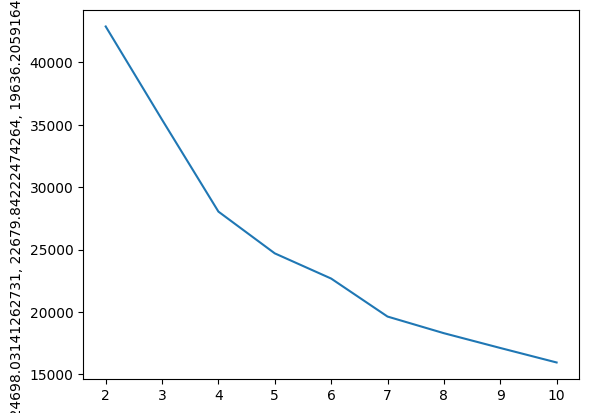

In [230]:
plt.plot(range(2,11),wcss)
plt.xticks(range(2,11))
plt.ylabel(wcss)
plt.show()

In [231]:
kl = KneeLocator(range(2,11),wcss,curve="convex",direction='decreasing')

In [232]:
kl.elbow

np.int64(4)

In [233]:
user_kmeans = KMeans(n_clusters=4,init="k-means++",random_state=42)
user_kmeans.fit(user_feature_clustering_scaled)
score = silhouette_score(user_feature_clustering_scaled,user_kmeans.labels_)
score

0.24025937882636775

In [234]:
silhouette_coeff

[0.3365555175914549,
 0.2045783244260137,
 0.24025937882636775,
 0.21392665395390392,
 0.21706169575585,
 0.2554302857988989,
 0.2541118872005252,
 0.2142251804687185,
 0.2209685023927449]

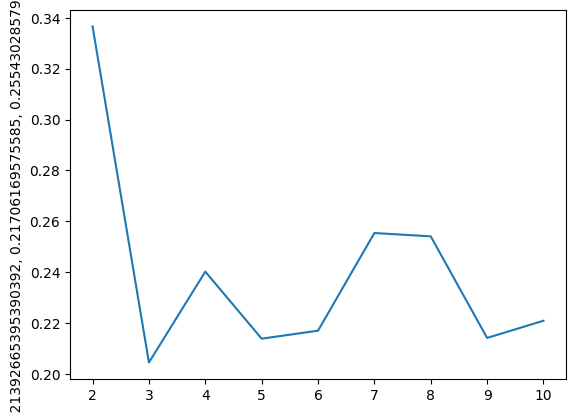

In [235]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.ylabel(silhouette_coeff)
plt.show()

In [ ]:
user_feature_clustering['user_cluster'] = user_kmeans.fit_predict(user_feature_clustering_scaled)

# Check distribution
print(user_feature_clustering['user_cluster'].value_counts().sort_index())

user_cluster
0    2658
1    1004
2    3500
3     645
Name: count, dtype: int64


In [237]:
import joblib

In [238]:
joblib.dump(User_scaled, r'd:\BookRecommendation\ml_models\user_scaled.pkl')

['d:\\BookRecommendation\\ml_models\\user_scaled.pkl']

In [239]:
joblib.dump(user_kmeans, r'd:\BookRecommendation\ml_models\user_kmeans.pkl')

['d:\\BookRecommendation\\ml_models\\user_kmeans.pkl']

In [240]:
user_feature.to_csv(r'd:\BookRecommendation\data\processed\user_features.csv', index=False)

In [241]:
user_clusters = user_feature.copy()
user_clusters['user_cluster'] = user_kmeans.fit_predict(user_feature_clustering_scaled)
user_clusters.to_csv(r'd:\BookRecommendation\data\processed\user_clusters.csv', index=False)

In [173]:
book_feature.info()

<class 'pandas.DataFrame'>
RangeIndex: 5175 entries, 0 to 5174
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ISBN                   5175 non-null   str    
 1   Book_avg_rating        5175 non-null   float64
 2   Book_rating_count      5175 non-null   int64  
 3   Book_rating_std        5175 non-null   float64
 4   Year_Of_Publication    5175 non-null   int64  
 5   Publisher              5175 non-null   str    
 6   Genre                  5175 non-null   str    
 7   Title_Author_combined  5175 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 667.5 KB


In [174]:
book_feature['Genre'].nunique()

74

In [175]:
book_feature['Genre'].unique()

<ArrowStringArray>
[                      'Fiction',         'Religious Non-fiction',
            'Historical Fiction',                     'Adventure',
                'Technothriller',                      'Thriller',
                       'Classic',                     'Biography',
                       'Romance',                 'Crime Fiction',
                         'Crime',                       'Unknown',
             'Religious Fiction',                'Legal Thriller',
              'Literary Fiction',                    'Philosophy',
               'Science Fiction',                   'Non-Fiction',
                       'Mystery',                 'Inspirational',
                        'Horror',               'Magical Realism',
                        'Gothic',                     'Dystopian',
                   'Young Adult',              'Medical Thriller',
                        'Memoir',                       'Fantasy',
                      'Children',          

In [176]:
genre_mapping = {
    # Fiction
    'Fiction': 'Fiction',
    'Literary Fiction': 'Fiction',
    'Classic Fiction': 'Fiction',
    'Comic Fiction': 'Fiction',
    'Classic': 'Fiction',

    # Mystery & Thriller
    'Thriller': 'Thriller_Mystery',
    'Mystery': 'Thriller_Mystery',
    'Crime Fiction': 'Thriller_Mystery',
    'Crime': 'Thriller_Mystery',
    'Crime Thriller': 'Thriller_Mystery',
    'Crime Mystery': 'Thriller_Mystery',
    'Legal Thriller': 'Thriller_Mystery',
    'Medical Thriller': 'Thriller_Mystery',
    'Technothriller': 'Thriller_Mystery',
    'Political Thriller': 'Thriller_Mystery',
    'Spy Thriller': 'Thriller_Mystery',
    'Military Thriller': 'Thriller_Mystery',
    'Historical Thriller': 'Thriller_Mystery',
    'Psychological Thriller': 'Thriller_Mystery',
    'Suspense Thriller': 'Thriller_Mystery',
    'Cozy Mystery': 'Thriller_Mystery',
    'Historical Mystery': 'Thriller_Mystery',
    'Horror/Thriller': 'Thriller_Mystery',
    'Romantic Thriller': 'Thriller_Mystery',
    'Crime Comedy': 'Thriller_Mystery',
    'True Crime': 'Thriller_Mystery',

    # Romance
    'Romance': 'Romance',
    'Historical Romance': 'Romance',
    'Romantic Suspense': 'Romance',
    'Romance/Drama': 'Romance',
    'Romance/Suspense': 'Romance',
    'Chick Lit': 'Romance',
    'Drama/Romance': 'Romance',
    'Erotic Fiction': 'Romance',

    # Science Fiction & Fantasy
    'Science Fiction': 'SciFi_Fantasy',
    'Fantasy': 'SciFi_Fantasy',
    'Dystopian': 'SciFi_Fantasy',
    'Paranormal': 'SciFi_Fantasy',
    'Magical Realism': 'SciFi_Fantasy',
    "Children's Fantasy": 'SciFi_Fantasy',

    # Horror
    'Horror': 'Horror',
    'Gothic': 'Horror',
    'Gothic Fiction': 'Horror',
    'Comic Horror': 'Horror',

    # Historical
    'Historical Fiction': 'Historical',
    'Historical Non-Fiction': 'Historical',

    # Non Fiction
    'Non-Fiction': 'Non_Fiction',
    'Religious Non-fiction': 'Non_Fiction',
    'Biography': 'Non_Fiction',
    'Biography/Non-fiction': 'Non_Fiction',
    'Memoir': 'Non_Fiction',
    'Self-Help': 'Non_Fiction',
    'Inspirational': 'Non_Fiction',
    'Philosophy': 'Non_Fiction',
    'Philosophical Fiction': 'Non_Fiction',
    'Psychology': 'Non_Fiction',
    'Health': 'Non_Fiction',
    'Travel': 'Non_Fiction',
    'True Crime': 'Non_Fiction',
    'Popular Science/Non-fiction': 'Non_Fiction',
    'Spiritual/Non-fiction': 'Non_Fiction',
    'Non-fiction/Survival': 'Non_Fiction',

    # Religious
    'Religious Fiction': 'Religious',

    # Adventure
    'Adventure': 'Adventure',
    'War Fiction': 'War_Adventure',
    'Sports Fiction': 'Adventure',

    # Children
    'Children': 'Children',
    "Children's Fiction": 'Children',
    'Young Adult': 'Young_Adult',

    # Drama & Humor
    'Drama': 'Drama_Humor',
    'Family Drama': 'Drama_Humor',
    'Satire': 'Drama_Humor',
    'Humor': 'Drama_Humor',

    # Biography
    'Unknown': 'Unknown',
}

book_feature['Genre_grouped'] = book_feature['Genre'].map(genre_mapping).fillna('Other')

print(book_feature['Genre_grouped'].value_counts())
print(f"\nUnique genres after mapping: {book_feature['Genre_grouped'].nunique()}")

Genre_grouped
Thriller_Mystery    1390
Fiction             1030
Unknown              776
Romance              707
SciFi_Fantasy        363
Horror               268
Historical           209
Non_Fiction          196
Children             102
Drama_Humor           71
Young_Adult           32
Other                 10
Adventure              9
Religious              8
War_Adventure          4
Name: count, dtype: int64

Unique genres after mapping: 15


In [177]:
book_feature

,ISBN,Book_avg_rating,Book_rating_count,Book_rating_std,Year_Of_Publication,Publisher,Genre,Title_Author_combined,Genre_grouped
0,0399135782,3.954545,22,3.954545,1991,Putnam Pub Group,Fiction,The Kitchen God's Wife Amy Tan,Fiction
1,0440234743,2.325175,286,2.325175,1999,Dell,Religious Non-fiction,The Testament John Grisham,Non_Fiction
2,0452264464,3.083969,131,3.083969,1994,Plume,Historical Fiction,Beloved (Plume Contemporary Fiction) Toni Morr...,Historical
3,0971880107,0.641571,1222,0.641571,2004,Too Far,Adventure,Wild Animus Rich Shapero,Adventure
4,0345402871,2.078571,140,2.078571,1997,Ballantine Books,Technothriller,Airframe Michael Crichton,Thriller_Mystery
...,...,...,...,...,...,...,...,...,...
5170,0689823185,0.000000,1,0.000000,1998,Simon Pulse,Romance,Where You Belong Mary Ann McGuigan,Romance
5171,0553290703,9.000000,1,9.000000,1992,Bantam Books,Thriller,Lightning Patricia Potter,Thriller_Mystery
5172,0345478940,0.000000,1,0.000000,2004,Ballantine Books,Romance,Angel Falls KRISTIN HANNAH,Romance
5173,B00011SOYM,0.000000,1,0.000000,2002,Scribner,Crime,Grave Secrets Kathy Reichs,Thriller_Mystery


In [178]:
book_feature['Genre_grouped']

0                Fiction
1            Non_Fiction
2             Historical
3              Adventure
4       Thriller_Mystery
              ...       
5170             Romance
5171    Thriller_Mystery
5172             Romance
5173    Thriller_Mystery
5174             Unknown
Name: Genre_grouped, Length: 5175, dtype: str

In [179]:
book_feature_clustering = book_feature.copy()

In [180]:
book_feature_clustering.columns

Index(['ISBN', 'Book_avg_rating', 'Book_rating_count', 'Book_rating_std',
       'Year_Of_Publication', 'Publisher', 'Genre', 'Title_Author_combined',
       'Genre_grouped'],
      dtype='str')

In [181]:
book_feature_clustering.drop(columns=['ISBN','Publisher','Genre','Title_Author_combined'],inplace=True)

In [182]:
book_feature_clustering

,Book_avg_rating,Book_rating_count,Book_rating_std,Year_Of_Publication,Genre_grouped
0,3.954545,22,3.954545,1991,Fiction
1,2.325175,286,2.325175,1999,Non_Fiction
2,3.083969,131,3.083969,1994,Historical
3,0.641571,1222,0.641571,2004,Adventure
4,2.078571,140,2.078571,1997,Thriller_Mystery
...,...,...,...,...,...
5170,0.000000,1,0.000000,1998,Romance
5171,9.000000,1,9.000000,1992,Thriller_Mystery
5172,0.000000,1,0.000000,2004,Romance
5173,0.000000,1,0.000000,2002,Thriller_Mystery


In [183]:
median_year = book_feature[book_feature['Year_Of_Publication'] != 0]['Year_Of_Publication'].median()
book_feature['Year_Of_Publication'] = book_feature['Year_Of_Publication'].replace(0, median_year)
book_feature_clustering['Year_Of_Publication'] = book_feature_clustering['Year_Of_Publication'].replace(0, median_year)


In [200]:
median_year

np.float64(1997.0)

In [184]:
book_categorical_feature = [x for x in book_feature_clustering.columns if x == 'Genre_grouped']
book_numerical_feature =  [x for x in book_feature_clustering.columns if x != 'Genre_grouped']

In [185]:
book_numerical_feature

['Book_avg_rating',
 'Book_rating_count',
 'Book_rating_std',
 'Year_Of_Publication']

In [186]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [187]:
book_std = StandardScaler()
book_ohe = OneHotEncoder(drop='first',sparse_output=False)

Book_scaled = ColumnTransformer([
    ('StandardScaler',book_std , book_numerical_feature ),
    ('OneHotEncoder',book_ohe , book_categorical_feature)
],remainder='drop')

In [188]:
book_feature_clustering_scaled = Book_scaled.fit_transform(book_feature_clustering)

In [201]:
book_feature_clustering_scaled 

array([[ 0.58634313, -0.25811894,  0.58634313, ...,  0.        ,
         0.        ,  0.        ],
       [-0.16031627,  4.47329974, -0.16031627, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.18740152,  1.69538347,  0.18740152, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.22582809, -0.63448179, -1.22582809, ...,  0.        ,
         0.        ,  0.        ],
       [-1.22582809, -0.63448179, -1.22582809, ...,  0.        ,
         0.        ,  0.        ],
       [ 3.35667384, -0.63448179,  3.35667384, ...,  1.        ,
         0.        ,  0.        ]], shape=(5175, 18))

In [189]:
feature_names = Book_scaled.get_feature_names_out()

book_feature_clustering_scale = pd.DataFrame(
    book_feature_clustering_scaled,
    columns=feature_names
)

In [190]:
pd.DataFrame(book_feature_clustering_scaled)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.586343,-0.258119,0.586343,-0.529105,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.160316,4.473300,-0.160316,0.487602,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.187402,1.695383,0.187402,-0.147840,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.931828,21.248330,-0.931828,1.123043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.273322,1.856682,-0.273322,0.233425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5170,-1.225828,-0.634482,-1.225828,0.360513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5171,2.898424,-0.634482,2.898424,-0.402016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5172,-1.225828,-0.634482,-1.225828,1.123043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5173,-1.225828,-0.634482,-1.225828,0.868866,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [191]:
wcss_book = []
silhouette_coeff_book = []

for i in range(2,11):
    book_kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    book_kmeans.fit_transform(book_feature_clustering_scaled)
    wcss_book.append(book_kmeans.inertia_)
    score = silhouette_score(book_feature_clustering_scaled,book_kmeans.labels_)
    silhouette_coeff_book.append(score)


In [192]:
wcss_book

[18560.076656359644,
 15279.025754446615,
 13332.25273903671,
 11248.50282957562,
 10215.57986729542,
 9649.906787703547,
 9054.805528484705,
 8386.43829607467,
 7925.154367880288]

In [193]:
silhouette_coeff_book

[0.3459128784757874,
 0.21760637071718714,
 0.21611883906067245,
 0.23653450910244478,
 0.21530698614595076,
 0.21659339228965058,
 0.19280230706651524,
 0.19552178943069085,
 0.2073645025848788]

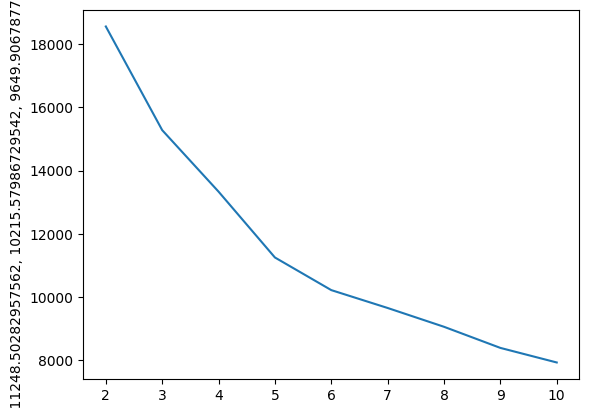

In [194]:
plt.plot(range(2,11),wcss_book)
plt.xticks(range(2,11))
plt.ylabel(wcss_book)
plt.show()

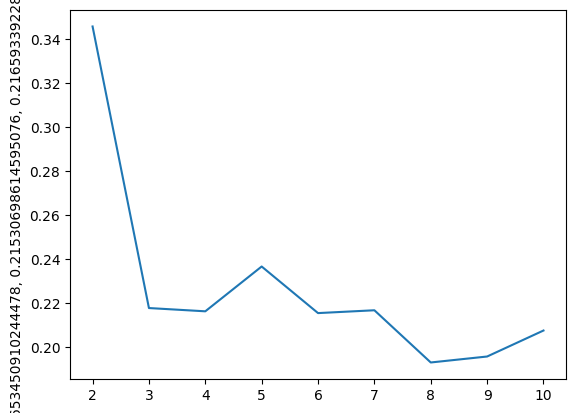

In [195]:
plt.plot(range(2,11),silhouette_coeff_book)
plt.xticks(range(2,11))
plt.ylabel(silhouette_coeff_book)
plt.show()

In [196]:
kl_book = KneeLocator(range(2,11),wcss_book,curve="convex",direction='decreasing')

In [197]:
kl_book.elbow

np.int64(5)

In [204]:
book_kmeans = KMeans(n_clusters=5, random_state=42, init='k-means++')
book_feature_clustering['book_cluster'] = book_kmeans.fit_predict(book_feature_clustering_scaled)
print(book_feature_clustering['book_cluster'].value_counts().sort_index())

book_cluster
0     639
1    1337
2     397
3     440
4    2362
Name: count, dtype: int64


In [205]:
book_feature_clustering

,Book_avg_rating,Book_rating_count,Book_rating_std,Year_Of_Publication,Genre_grouped,book_cluster
0,3.954545,22,3.954545,1991,Fiction,4
1,2.325175,286,2.325175,1999,Non_Fiction,2
2,3.083969,131,3.083969,1994,Historical,2
3,0.641571,1222,0.641571,2004,Adventure,2
4,2.078571,140,2.078571,1997,Thriller_Mystery,2
...,...,...,...,...,...,...
5170,0.000000,1,0.000000,1998,Romance,1
5171,9.000000,1,9.000000,1992,Thriller_Mystery,3
5172,0.000000,1,0.000000,2004,Romance,1
5173,0.000000,1,0.000000,2002,Thriller_Mystery,1


In [206]:
import joblib

In [207]:
print(os.getcwd())

d:\BookRecommendation\notebook


In [208]:
joblib.dump(Book_scaled, r'd:\BookRecommendation\ml_models\book_scaled.pkl')

['d:\\BookRecommendation\\ml_models\\book_scaled.pkl']

In [209]:
joblib.dump(book_kmeans, r'd:\BookRecommendation\ml_models\book_kmeans.pkl')

['d:\\BookRecommendation\\ml_models\\book_kmeans.pkl']

In [213]:
book_feature.to_csv(r'd:\BookRecommendation\data\processed\book_features.csv', index=False)

In [214]:
book_clusters = book_feature.copy()
book_clusters['book_cluster'] = book_kmeans.fit_predict(book_feature_clustering_scaled)
book_clusters.to_csv(r'd:\BookRecommendation\data\processed\book_clusters.csv', index=False)

In [210]:
user_feature

,User_ID,user_avg_rating,user_rating_count,user_rating_std,Age_Group,Country,favourite_author,old_books_ratio,recent_books_ratio,genre_diversity
0,8,0.000000,1,0.000000,Unknown,canada,Amy Tan,1.000000,0.000000,1
1,242,6.000000,3,5.291503,Middle_Age,germany,RAY BRADBURY,0.666667,0.333333,3
2,243,2.050847,59,3.486050,Unknown,usa,James Patterson,0.576271,0.423729,18
3,254,2.044944,89,3.720063,Young_Adult,usa,J. K. Rowling,0.685393,0.314607,19
4,383,1.250000,8,3.535534,Unknown,usa,John Grisham,0.250000,0.750000,5
...,...,...,...,...,...,...,...,...,...,...
7802,278582,5.529412,17,4.094473,Unknown,usa,Janet Evanovich,0.352941,0.647059,4
7803,278633,4.275000,40,4.138546,Unknown,usa,ANN BRASHARES,0.700000,0.300000,11
7804,278637,0.000000,1,0.000000,Unknown,france,Patricia Cornwell,1.000000,0.000000,1
7805,278843,3.869565,23,4.159374,Adult,usa,Rebecca Wells,0.782609,0.217391,6
